# Global Weather Dataset — Exploratory Data Analysis

**Dataset:** `weather_cleaned.csv` — hourly weather + air quality observations across 186 countries / 217 locations, May 2024 – July 2026.

## Contents
1. [Setup & Data Loading](#1)
2. [Data Cleaning](#2)
3. [Dataset Overview](#3)
4. [Descriptive Statistics](#4)
5. [Distribution Analysis](#5)
6. [Correlation Analysis](#6)
7. [Temporal Analysis](#7)
8. [Weather Condition Analysis](#8)
9. [Air Quality Analysis](#9)
10. [Geographic Analysis](#10)
11. [Outlier Detection](#11)
12. [Livability Index](#12)
13. [Best Time to Visit](#13)
14. [Rush Hour Pollution Patterns](#14)
15. [Wind Power Potential](#15)
16. [UV Index Extremes](#16)
17. [Summary of Key Insights](#17)


<a id='1'></a>
## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
%matplotlib inline

df = pd.read_csv('weather_cleaned.csv', parse_dates=['last_updated'])
print('Raw shape:', df.shape)
df.head()

Raw shape: (153586, 38)


,country,location_name,latitude,longitude,timezone,last_updated,temperature_celsius,condition_text,wind_kph,wind_degree,...,sunset,moonrise,moonset,moon_phase,moon_illumination,year,month,month_name,day_of_week,hour
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,2024-05-16 13:15:00,26.6,Partly Cloudy,13.3,338.0,...,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55.0,2024,5,May,Thursday,13
1,Albania,Tirana,41.33,19.82,Europe/Tirane,2024-05-16 10:45:00,19.0,Partly cloudy,11.2,320.0,...,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55.0,2024,5,May,Thursday,10
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,2024-05-16 09:45:00,23.0,Sunny,15.1,280.0,...,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55.0,2024,5,May,Thursday,9
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,2024-05-16 10:45:00,6.3,Light drizzle,11.9,215.0,...,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55.0,2024,5,May,Thursday,10
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,2024-05-16 09:45:00,26.0,Partly cloudy,13.0,150.0,...,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55.0,2024,5,May,Thursday,9


<a id='2'></a>
## 2. Data Cleaning

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 153586 entries, 0 to 153585
Data columns (total 38 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   country                       153586 non-null  str           
 1   location_name                 153586 non-null  str           
 2   latitude                      153586 non-null  float64       
 3   longitude                     153586 non-null  float64       
 4   timezone                      153586 non-null  str           
 5   last_updated                  153586 non-null  datetime64[us]
 6   temperature_celsius           153585 non-null  float64       
 7   condition_text                153586 non-null  str           
 8   wind_kph                      153585 non-null  float64       
 9   wind_degree                   153586 non-null  float64       
 10  wind_direction                153586 non-null  str           
 11  pressure_mb             

In [3]:
# Missing values
missing_summary = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_percentage': (df.isna().mean() * 100).round(4)
})
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values(
    'missing_percentage', ascending=False)
display(missing_summary)

,missing_count,missing_percentage
pressure_mb,2,0.0013
air_quality_PM10,2,0.0013
wind_kph,1,0.0007
temperature_celsius,1,0.0007
feels_like_celsius,1,0.0007
gust_kph,1,0.0007
air_quality_Carbon_Monoxide,1,0.0007
air_quality_Sulphur_dioxide,1,0.0007


In [4]:
# Drop the handful of incomplete rows (well under 0.01% of the data)
rows_before = len(df)
df = df.dropna().copy()
print(f'Rows dropped for missing values: {rows_before - len(df)}')

Rows dropped for missing values: 8


In [5]:
# Check for duplicate country/location/timestamp records
print('Exact duplicate rows:', df.duplicated().sum())

location_time_duplicates = df.duplicated(
    subset=['country', 'location_name', 'last_updated'], keep=False)
print('Duplicate country-location-time rows:', location_time_duplicates.sum())

rows_before = len(df)
df = df.drop_duplicates(subset=['country', 'location_name', 'last_updated'], keep='first').copy()
print(f'Rows removed as duplicates: {rows_before - len(df)}')
print(f'Final row count: {len(df):,}')

Exact duplicate rows: 0
Duplicate country-location-time rows: 2
Rows removed as duplicates: 1
Final row count: 153,577


<a id='3'></a>
## 3. Dataset Overview

In [6]:
overview = {
    'Observations': len(df),
    'Columns': df.shape[1],
    'Countries': df['country'].nunique(),
    'Unique locations': df['location_name'].nunique(),
    'Country-location pairs': df[['country', 'location_name']].drop_duplicates().shape[0],
    'Start date': df['last_updated'].min(),
    'End date': df['last_updated'].max()
}
display(pd.DataFrame(overview.items(), columns=['Metric', 'Value']))

,Metric,Value
0,Observations,153577
1,Columns,38
2,Countries,186
3,Unique locations,217
4,Country-location pairs,219
5,Start date,2024-05-16 02:45:00
6,End date,2026-07-18 19:00:00


**Insight:** The dataset spans just over two years (May 2024 – July 2026) across 186 countries and 217 distinct locations, giving broad geographic and seasonal coverage for climate-style comparisons.

<a id='4'></a>
## 4. Descriptive Statistics

In [7]:
weather_columns = [
    'temperature_celsius', 'feels_like_celsius', 'humidity', 'pressure_mb',
    'wind_kph', 'gust_kph', 'precip_mm', 'visibility_km', 'cloud', 'uv_index'
]

descriptive_stats = df[weather_columns].describe().T
descriptive_stats['median'] = df[weather_columns].median()
descriptive_stats['skewness'] = df[weather_columns].skew()
descriptive_stats = descriptive_stats[
    ['count', 'mean', 'median', 'std', 'min', '25%', '50%', '75%', 'max', 'skewness']]
display(descriptive_stats.round(2))

,count,mean,median,std,min,25%,50%,75%,max,skewness
temperature_celsius,153577.0,21.36,23.7,9.48,-29.8,16.1,23.7,27.90,49.20,-0.83
feels_like_celsius,153577.0,22.14,25.0,11.38,-36.7,15.9,25.0,29.80,51.20,-0.78
humidity,153577.0,66.96,72.0,23.63,2.0,52.0,72.0,86.00,100.00,-0.67
pressure_mb,153577.0,1014.03,1014.0,6.89,947.0,1010.0,1014.0,1018.00,1080.00,0.04
wind_kph,153577.0,12.76,10.8,8.37,3.6,6.1,10.8,17.60,272.20,1.62
gust_kph,153577.0,18.07,15.1,11.22,3.6,10.0,15.1,24.00,279.40,1.48
precip_mm,153577.0,0.13,0.0,0.56,0.0,0.0,0.0,0.02,42.24,18.16
visibility_km,153577.0,9.51,10.0,2.68,0.0,10.0,10.0,10.00,32.00,1.05
cloud,153577.0,39.46,26.0,34.08,0.0,0.0,26.0,75.00,100.00,0.26
uv_index,153577.0,3.19,1.6,3.51,0.0,0.0,1.6,6.00,16.30,0.96


**Insight:**
- Average temperature is **21.4°C** (feels-like 22.1°C), ranging from **-29.8°C to 49.2°C** — a huge spread reflecting the dataset's global reach.
- Humidity averages **67%**, skewed toward humid conditions (skew -0.67).
- Pressure is tightly centered around **1014 mb** with almost no skew (0.04) — the most stable variable in the set.
- Wind (skew 1.62) and gust (1.48) speeds are right-skewed: most readings are calm, with a long tail of storm events.
- Precipitation is the most extreme case (skew **18.2**) — the median is 0 mm, meaning most hours see no rain at all, with rare heavy-rain outliers pulling the mean up.
- UV index (skew 0.96) is similarly weighted toward low/moderate values, as expected given most readings aren't at solar noon in the tropics.

<a id='5'></a>
## 5. Distribution Analysis

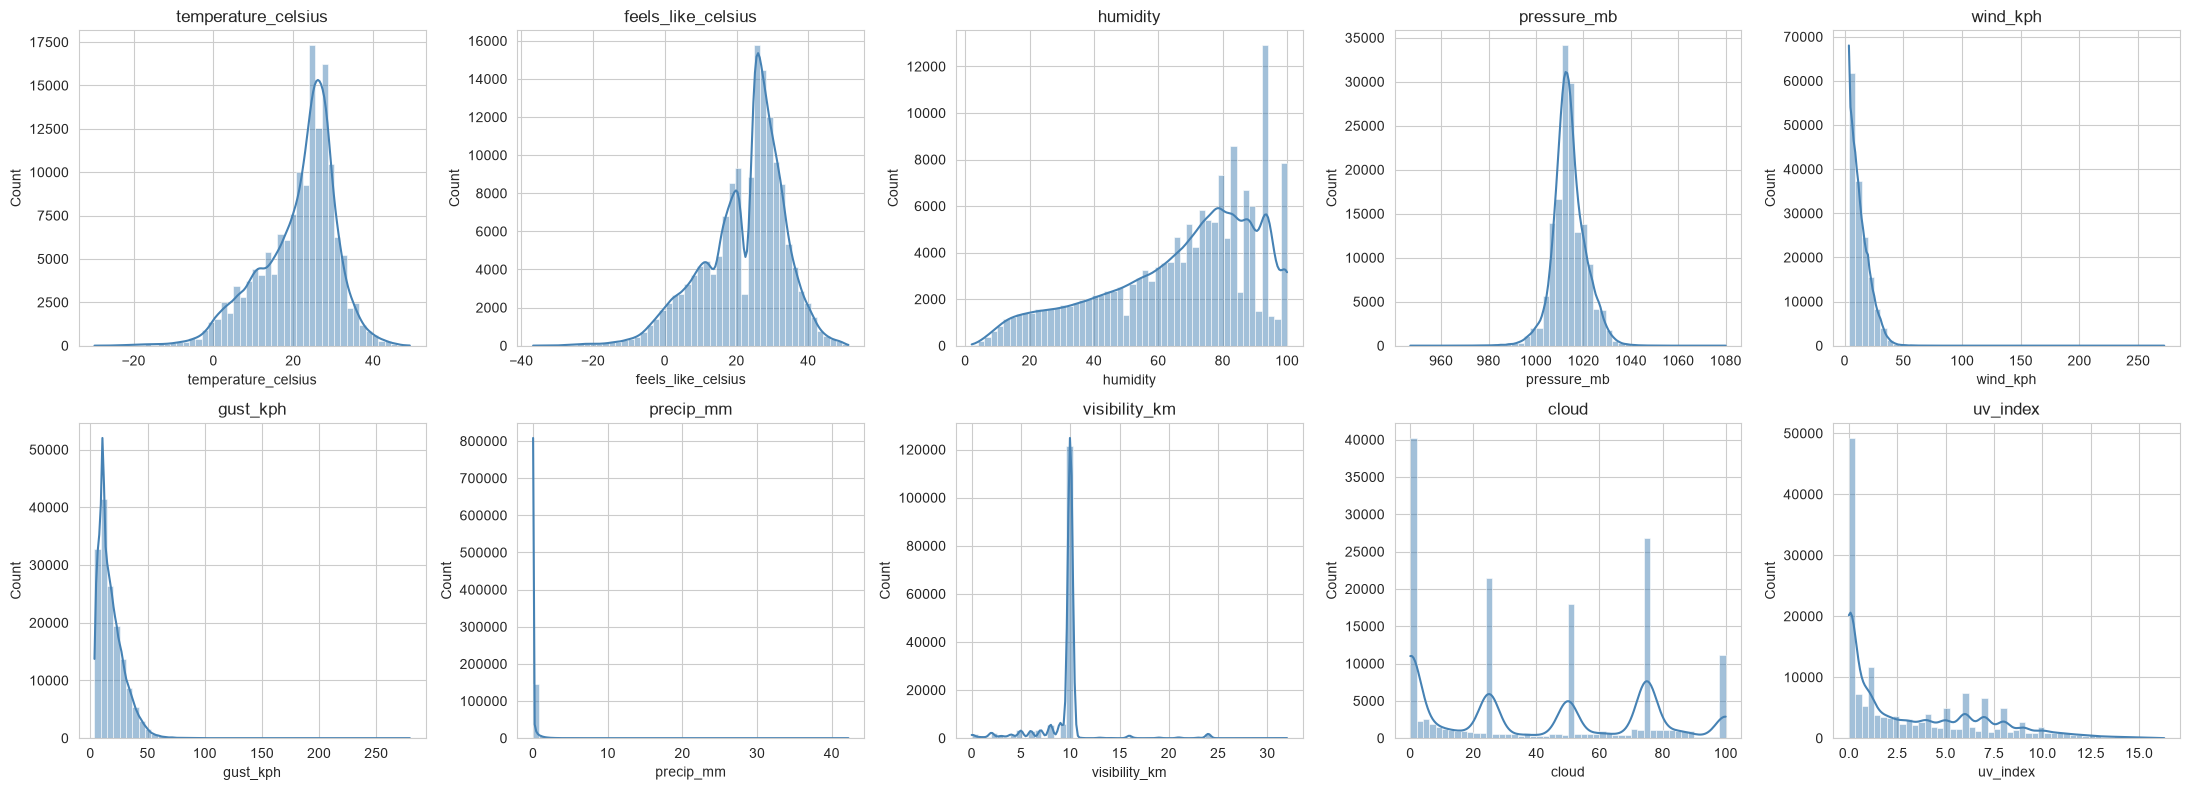

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
for ax, col in zip(axes.flat, weather_columns):
    sns.histplot(df[col], bins=50, ax=ax, kde=True, color='steelblue')
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Insight:** Most weather variables are non-normal, which is typical for meteorological data:
- **Temperature / feels-like:** moderately left-skewed, concentrated 20-30°C, with a longer cold tail.
- **Humidity:** concentrated 60-90%, left-skewed — dry conditions are comparatively rare in this sample.
- **Pressure:** the one genuinely bell-shaped variable, centered at 1014 mb.
- **Wind / gust speed:** strongly right-skewed, most readings are light wind, with rare high-speed events creating a long tail.
- **Precipitation:** an extreme spike at zero, the vast majority of hours are dry.
- **Cloud cover:** spread across the full 0-100% range with visible peaks at round numbers (0, 25, 50, 75, 100), a reporting artifact rather than a true continuous signal.
- **UV index:** right-skewed toward low/moderate values, with high-UV readings comparatively rare.

<a id='6'></a>
## 6. Correlation Analysis

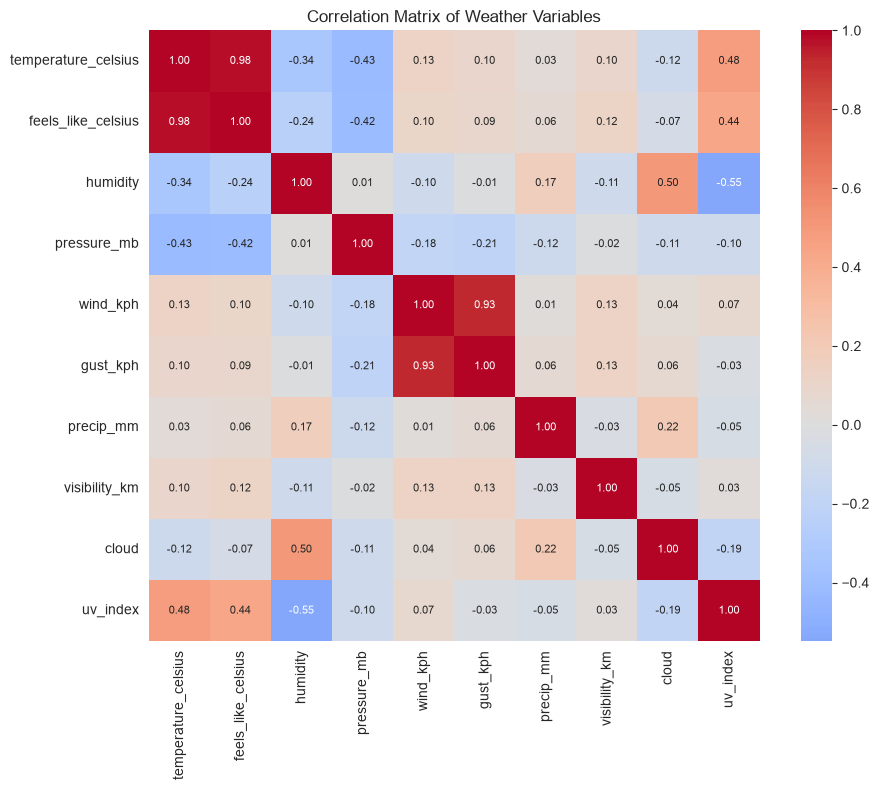

In [9]:
corr_matrix = df[weather_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, annot_kws={'size': 8})
plt.title('Correlation Matrix of Weather Variables')
plt.tight_layout()
plt.show()

In [10]:
# Top correlated pairs (excluding self-correlation)
corr_pairs = (
    corr_matrix.where(~np.eye(corr_matrix.shape[0], dtype=bool))
    .stack().reset_index()
)
corr_pairs.columns = ['Variable 1', 'Variable 2', 'Correlation']
corr_pairs['Absolute'] = corr_pairs['Correlation'].abs()
corr_pairs = corr_pairs.sort_values('Absolute', ascending=False).drop_duplicates(subset='Absolute')
display(corr_pairs.head(10))

,Variable 1,Variable 2,Correlation,Absolute
1,temperature_celsius,feels_like_celsius,0.980275,0.980275
54,gust_kph,wind_kph,0.932244,0.932244
92,uv_index,humidity,-0.549063,0.549063
28,humidity,cloud,0.503171,0.503171
90,uv_index,temperature_celsius,0.484935,0.484935
19,feels_like_celsius,uv_index,0.435014,0.435014
30,pressure_mb,temperature_celsius,-0.425128,0.425128
13,feels_like_celsius,pressure_mb,-0.421862,0.421862
2,temperature_celsius,humidity,-0.340488,0.340488
21,humidity,feels_like_celsius,-0.243558,0.243558


**Insight:** The strongest relationships all make physical sense:
- **Temperature vs feels-like (r = 0.98):** near-perfect, since feels-like is derived directly from temperature.
- **Wind vs gust speed (r = 0.93):** locations with strong sustained wind also see strong gusts.
- **UV index vs humidity (r = -0.55):** more humid/cloudy conditions block solar radiation.
- **Humidity vs cloud cover (r = 0.50)** and **temperature vs UV (r = 0.48)** are moderate and expected.
- **Pressure vs temperature (r = -0.43):** warmer conditions tend to coincide with lower-pressure systems.

Overall, the analysis indicates that while several weather variables exhibit strong linear relationships, many correlations are only moderate or weak. This reflects the complexity of atmospheric processes, where weather conditions are influenced by multiple interacting factors rather than a single variable.

<a id='7'></a>
## 7. Temporal Analysis

### 7.1 Data Coverage Check

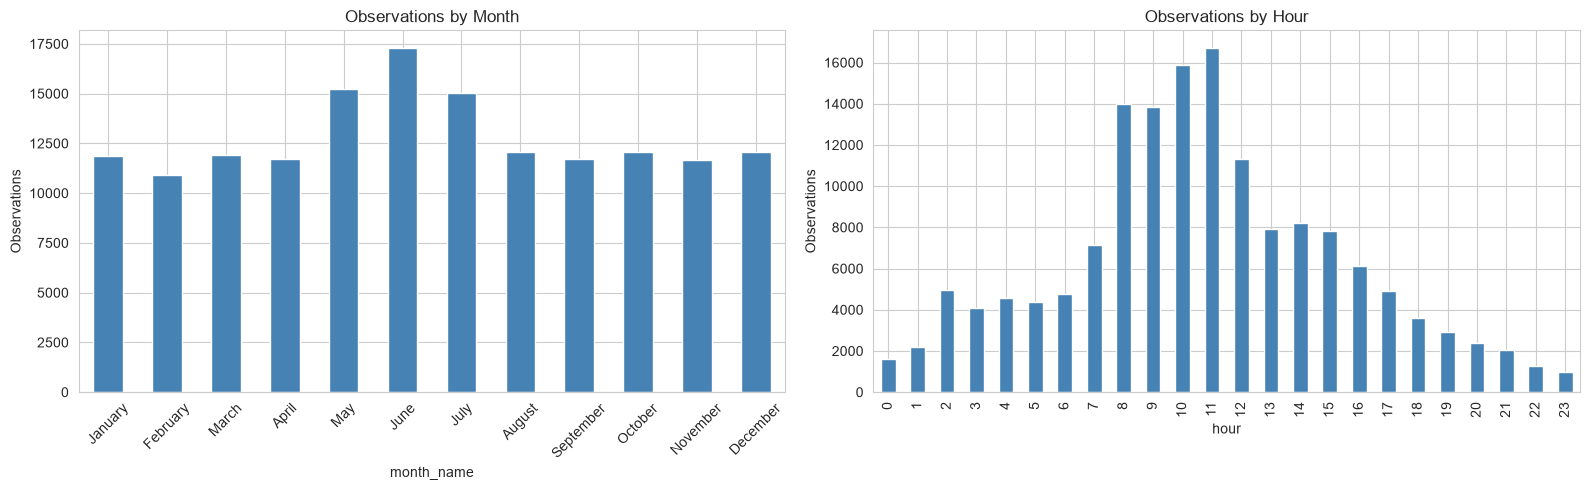

In [11]:
month_order = ['January','February','March','April','May','June','July','August',
               'September','October','November','December']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df.groupby('month_name', observed=False).size().reindex(month_order).plot(
    kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Observations by Month')
axes[0].set_ylabel('Observations')
axes[0].tick_params(axis='x', rotation=45)

df.groupby('hour').size().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Observations by Hour')
axes[1].set_ylabel('Observations')
plt.tight_layout()
plt.show()

**Insight:** Monthly coverage ranges from ~10,900 (February) to ~17,300 (June) observations. The higher counts in May-July mainly reflect the dataset's collection window (roughly May 2024 onward), not a genuine seasonal reporting bias. Hourly coverage is uneven too — this matters because simple hourly averages later in this notebook are not weighted by sample size, so months/hours with fewer readings carry proportionally more noise.

### 7.2 Seasonal Patterns (Monthly Averages)

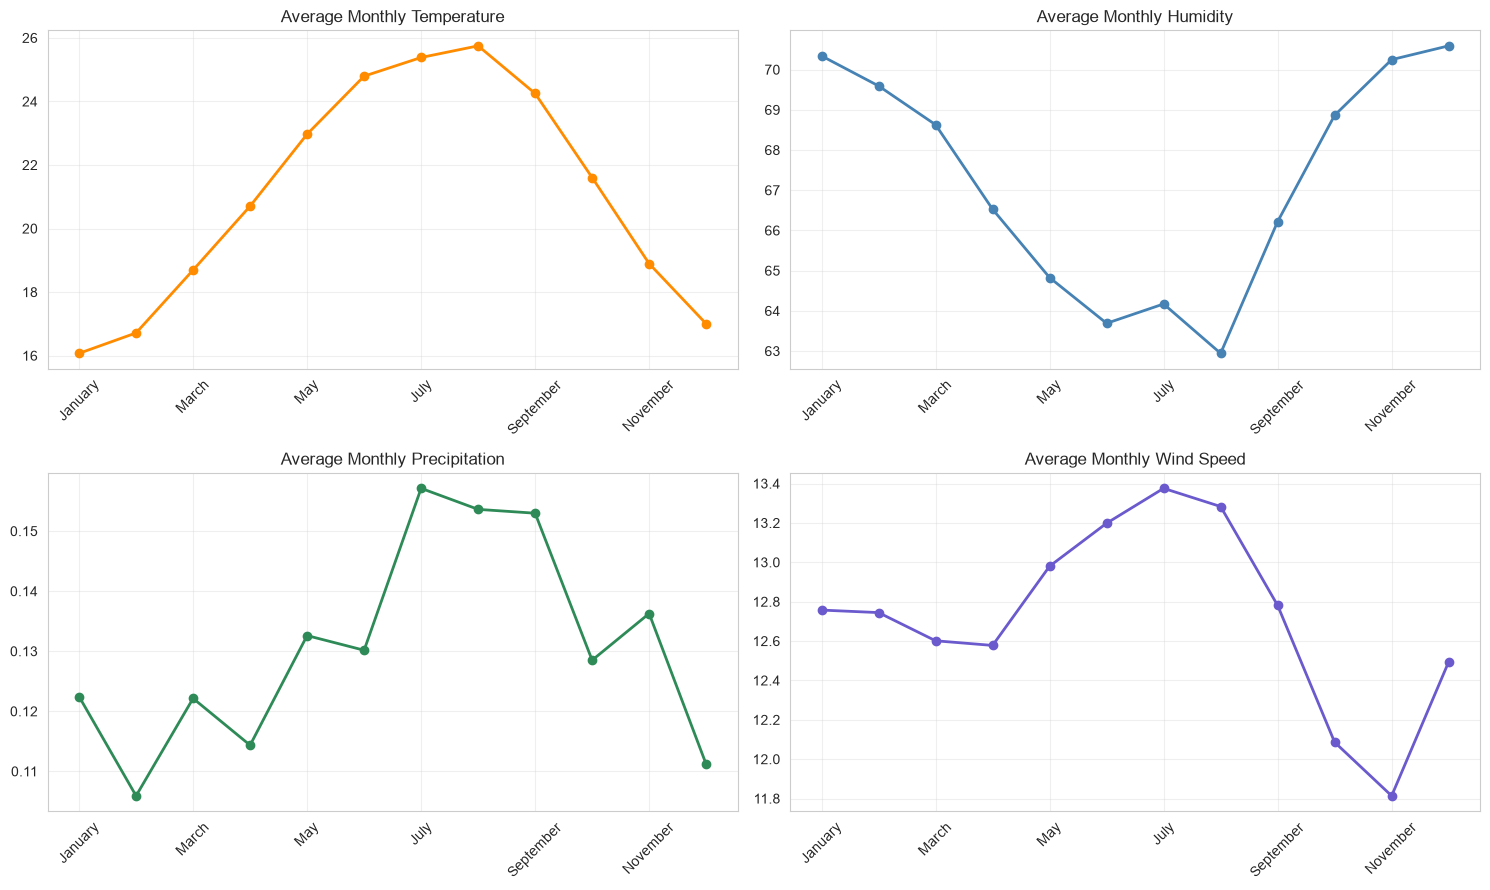

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

for ax, col, title, color in zip(
    axes.flat,
    ['temperature_celsius', 'humidity', 'precip_mm', 'wind_kph'],
    ['Average Monthly Temperature', 'Average Monthly Humidity',
     'Average Monthly Precipitation', 'Average Monthly Wind Speed'],
    ['darkorange', 'steelblue', 'seagreen', 'slateblue']
):
    df.groupby('month_name', observed=False)[col].mean().reindex(month_order).plot(
        marker='o', linewidth=2, ax=ax, color=color)
    ax.set_title(title)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Insight:**
- **Temperature** shows a clear annual cycle: lowest in January (16.1°C), peaking in August (25.7°C).
- **Humidity moves inversely to temperature** — highest in December (70.6%), lowest in August (62.9%).
- **Precipitation** stays low year-round but ticks up slightly through July-September.
- **Wind speed** is nearly flat across the year (roughly 11.8-13.4 kph), seasonality barely registers compared to temperature.


### 7.3 Daily Patterns (Hourly Averages)

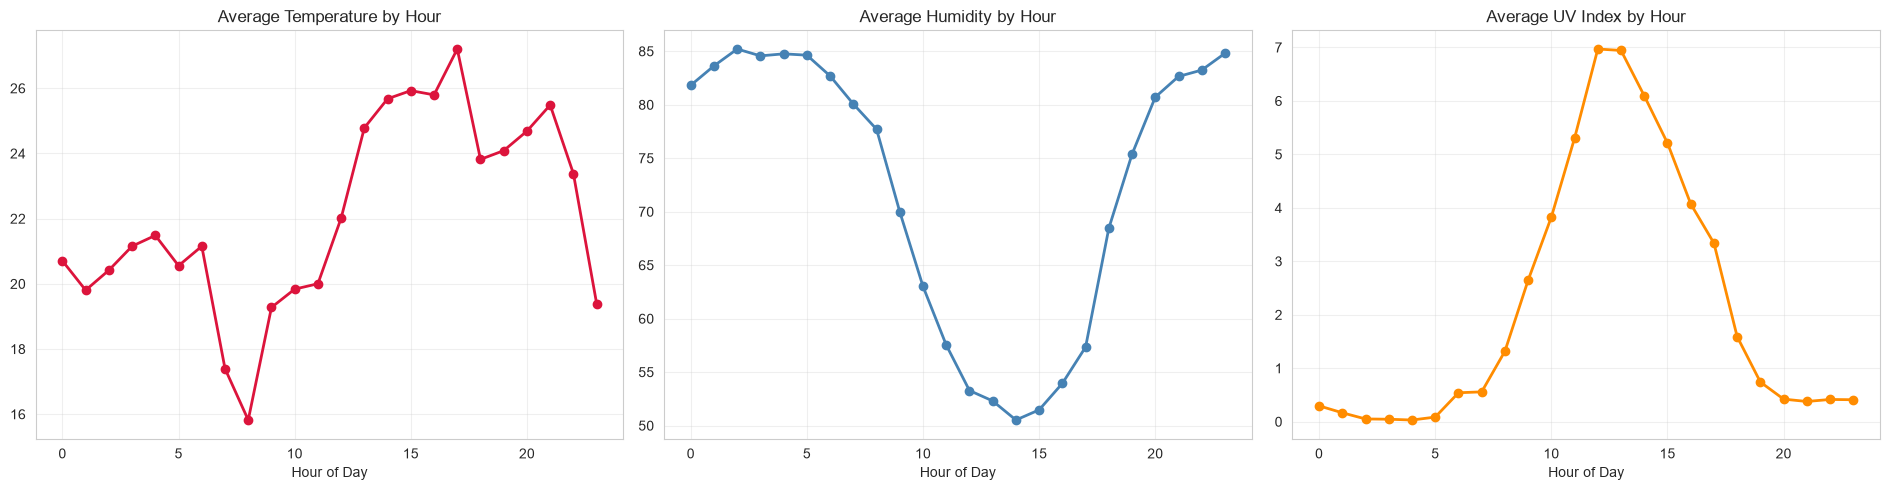

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

for ax, col, title, color in zip(
    axes,
    ['temperature_celsius', 'humidity', 'uv_index'],
    ['Average Temperature by Hour', 'Average Humidity by Hour', 'Average UV Index by Hour'],
    ['crimson', 'steelblue', 'darkorange']
):
    df.groupby('hour')[col].mean().plot(marker='o', linewidth=2, ax=ax, color=color)
    ax.set_title(title)
    ax.set_xlabel('Hour of Day')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Insight:** Clear daily cycles are visible, driven by the sun:
- **Temperature** troughs at 08:00 (15.8°C) and peaks at 17:00 (27.2°C).
- **Humidity** moves inversely, highest at 02:00 (85.2%), lowest at 14:00 (50.5%), consistent with warmer air holding more moisture and lowering relative humidity.
- **UV index** naturally peaks around midday when the sun is highest.

This confirms `hour` is a strong predictor of both temperature and humidity, reinforcing the negative correlation found earlier.

### 7.4 Month × Hour Interaction

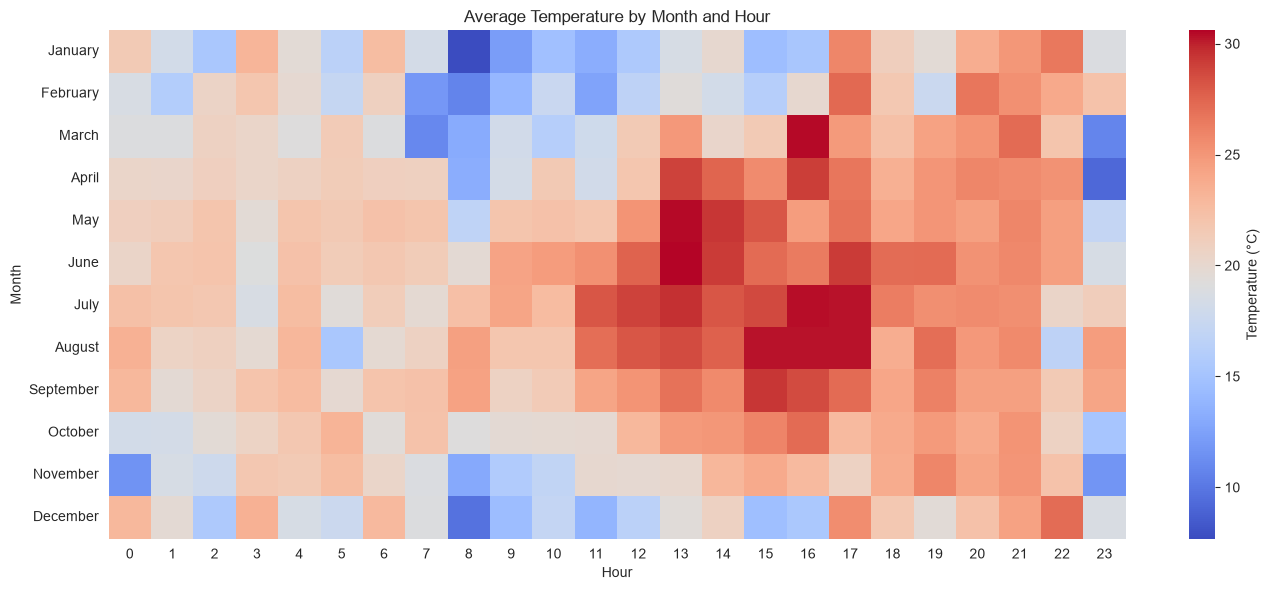

In [14]:
temp_heatmap = df.pivot_table(
    values='temperature_celsius', index='month_name', columns='hour',
    aggfunc='mean', observed=False
).reindex(month_order)

plt.figure(figsize=(14, 6))
sns.heatmap(temp_heatmap, cmap='coolwarm', cbar_kws={'label': 'Temperature (°C)'})
plt.title('Average Temperature by Month and Hour')
plt.xlabel('Hour')
plt.ylabel('Month')
plt.tight_layout()
plt.show()

**Insight:** The heatmap combines both cycles: afternoon hours (14:00-18:00) are consistently the warmest across every month, and the summer months (Jun-Aug) are warmest across every hour, the two seasonal and daily effects are independent and additive rather than interacting in any surprising way.

### 7.5 Day-of-Week Check (Data Quality)

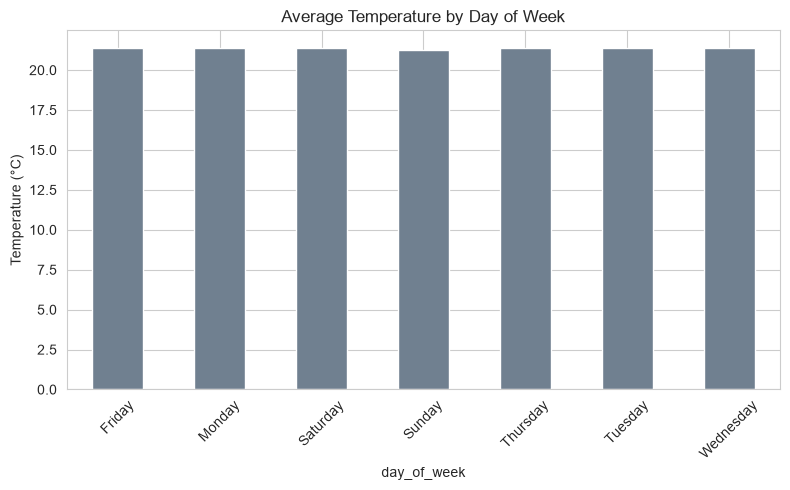

In [15]:
weekday_temperature = df.groupby('day_of_week', observed=False)['temperature_celsius'].mean()

weekday_temperature.plot(kind='bar', figsize=(8, 5), color='slategray')
plt.title('Average Temperature by Day of Week')
plt.ylabel('Temperature (°C)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:** Weather doesn't know what day of the week it is, so this chart is a sanity check rather than a real finding. Average temperature varies by only ~0.15°C across days — essentially flat, confirming there's no artificial weekly bias in the data collection.

### 7.6 Daylight Duration by Month

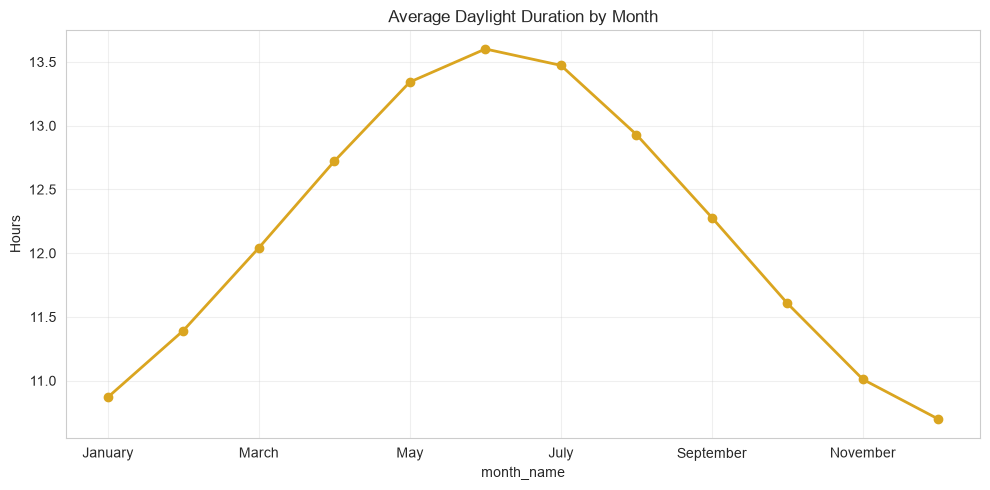

In [16]:
date_str = df['last_updated'].dt.date.astype(str)
df['sunrise_dt'] = pd.to_datetime(date_str + ' ' + df['sunrise'], format='%Y-%m-%d %I:%M %p')
df['sunset_dt'] = pd.to_datetime(date_str + ' ' + df['sunset'], format='%Y-%m-%d %I:%M %p')
df['daylight_hours'] = (df['sunset_dt'] - df['sunrise_dt']).dt.total_seconds() / 3600

monthly_daylight = df.groupby('month_name', observed=False)['daylight_hours'].mean().reindex(month_order)

plt.figure(figsize=(10, 5))
monthly_daylight.plot(marker='o', linewidth=2, color='goldenrod')
plt.title('Average Daylight Duration by Month')
plt.ylabel('Hours')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Insight:** Average daylight hours are fairly stable (the dataset mixes both hemispheres, so northern-summer and southern-winter locations partially cancel out globally) — this metric is far more informative when filtered to a single hemisphere or country.

<a id='8'></a>
## 8. Weather Condition Analysis

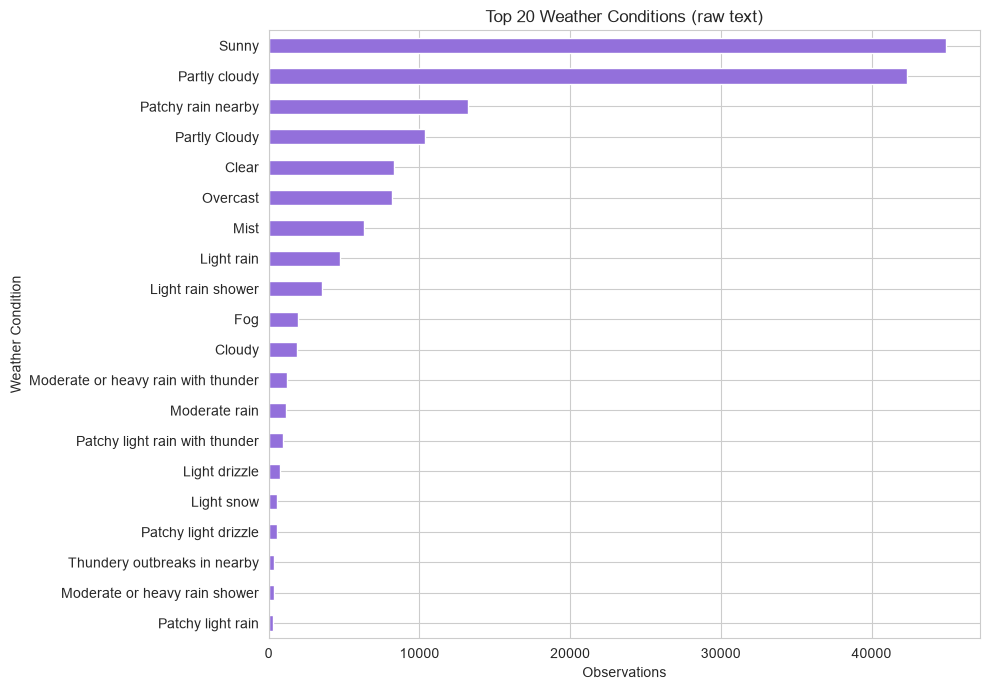

In [17]:
condition_counts = df['condition_text'].value_counts().reset_index()
condition_counts.columns = ['Weather Condition', 'Observations']

plt.figure(figsize=(10, 7))
condition_counts.head(20).set_index('Weather Condition')['Observations'].sort_values().plot(
    kind='barh', color='mediumpurple')
plt.title('Top 20 Weather Conditions (raw text)')
plt.xlabel('Observations')
plt.tight_layout()
plt.show()

**Insight:** The raw `condition_text` field has inconsistent casing (e.g. 'Partly cloudy' vs 'Partly Cloudy' are counted separately), which is why the next step groups conditions into broader, case-insensitive categories.

In [18]:
condition = df['condition_text'].str.lower()

conditions = [
    condition.str.contains('thunder|thundery', regex=True),
    condition.str.contains('snow|sleet|freezing|blizzard', regex=True),
    condition.str.contains('rain|drizzle|shower', regex=True),
    condition.str.contains('cloud|overcast', regex=True),
    condition.str.contains('sunny|clear', regex=True),
    condition.str.contains('fog|mist|haze|smog', regex=True),
    condition.str.contains('dust|sand', regex=True),
]
categories = ['Thunderstorm', 'Snow / Ice', 'Rain / Drizzle', 'Cloudy / Overcast',
              'Clear / Sunny', 'Fog / Haze', 'Dust / Sand']

df['weather_category'] = np.select(conditions, categories, default='Other')
df['weather_category'].value_counts()

weather_category
Cloudy / Overcast    62805
Clear / Sunny        53259
Rain / Drizzle       24706
Fog / Haze            8472
Thunderstorm          2733
Snow / Ice            1488
Dust / Sand            114
Name: count, dtype: int64

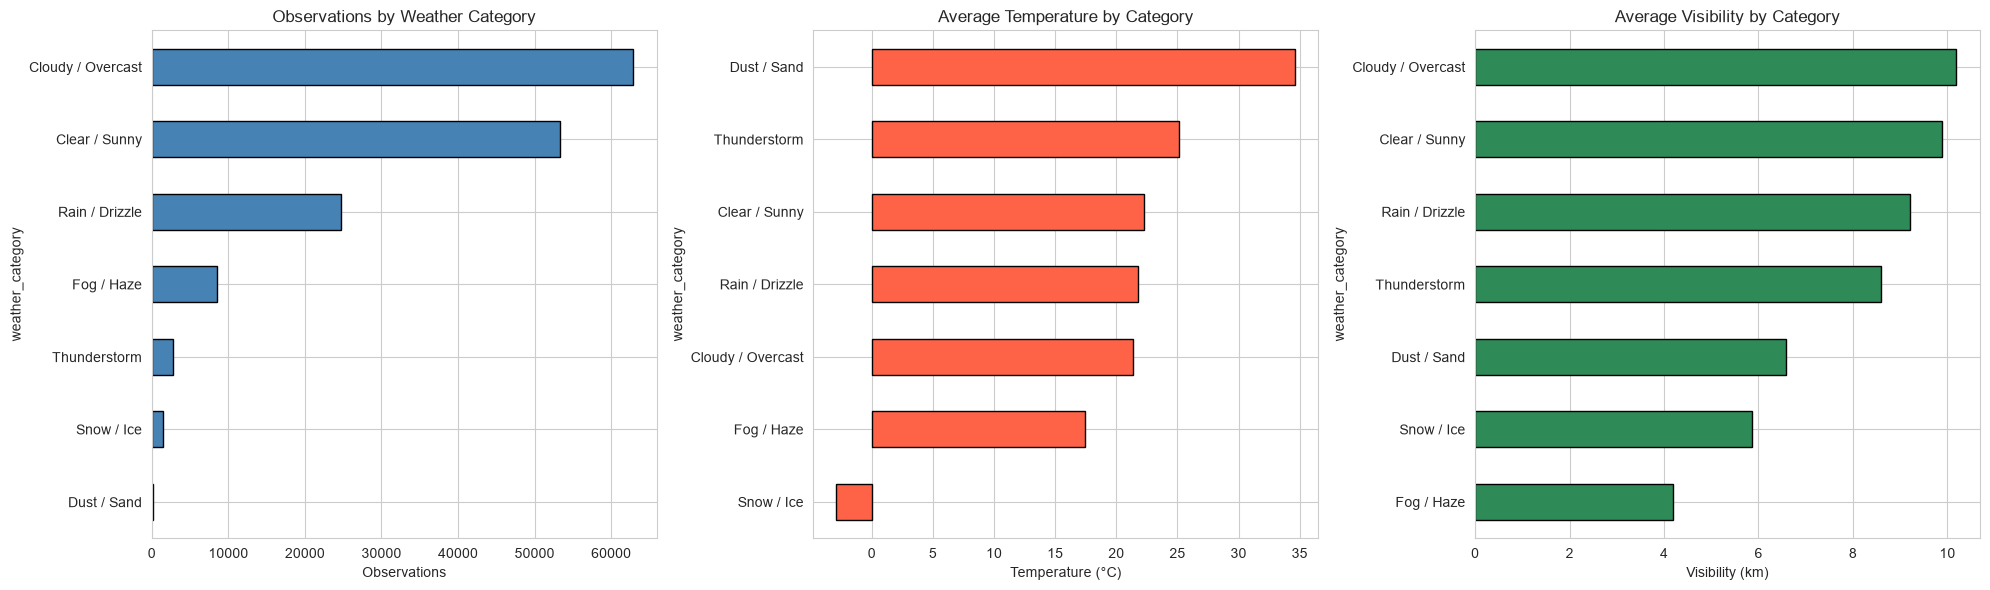

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

df['weather_category'].value_counts().sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Observations by Weather Category')
axes[0].set_xlabel('Observations')

df.groupby('weather_category')['temperature_celsius'].mean().sort_values().plot(
    kind='barh', ax=axes[1], color='tomato', edgecolor='black')
axes[1].set_title('Average Temperature by Category')
axes[1].set_xlabel('Temperature (°C)')

df.groupby('weather_category')['visibility_km'].mean().sort_values().plot(
    kind='barh', ax=axes[2], color='seagreen', edgecolor='black')
axes[2].set_title('Average Visibility by Category')
axes[2].set_xlabel('Visibility (km)')

plt.tight_layout()
plt.show()

**Insight:**
- **Cloudy/Overcast (62.8k)** and **Clear/Sunny (53.3k)** dominate, together over 75% of all readings; genuine severe weather (thunderstorms, snow/ice, dust) is rare (<3% combined).
- **Temperature ordering makes physical sense:** Snow/Ice is by far the coldest category (-2.9°C avg), Dust/Sand the hottest (34.7°C avg, reflecting desert dust events), with everything else in between.
- **Visibility ordering also matches expectations:** Fog/Haze has by far the lowest visibility (4.2 km), while Cloudy/Overcast and Clear/Sunny have the best visibility (~10 km) — cloud cover alone doesn't obstruct visibility the way fog does.

<a id='9'></a>
## 9. Air Quality Analysis

In [20]:
air_quality_columns = [
    'air_quality_Carbon_Monoxide', 'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
    'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10'
]
display(df[air_quality_columns].describe().T.round(2))

,count,mean,std,min,25%,50%,75%,max
air_quality_Carbon_Monoxide,153577.0,433.90,722.49,53.85,185.30,277.50,436.85,38879.40
air_quality_Ozone,153577.0,57.78,30.74,0.00,38.00,55.00,73.00,480.70
air_quality_Nitrogen_dioxide,153577.0,14.41,22.82,0.00,1.75,5.55,16.46,427.70
air_quality_Sulphur_dioxide,153577.0,9.94,22.13,0.00,1.11,2.40,7.77,521.33
air_quality_PM2.5,153577.0,23.33,35.40,0.17,6.90,13.55,26.64,1614.10
air_quality_PM10,153577.0,46.88,144.05,0.17,9.70,19.24,40.10,6037.29


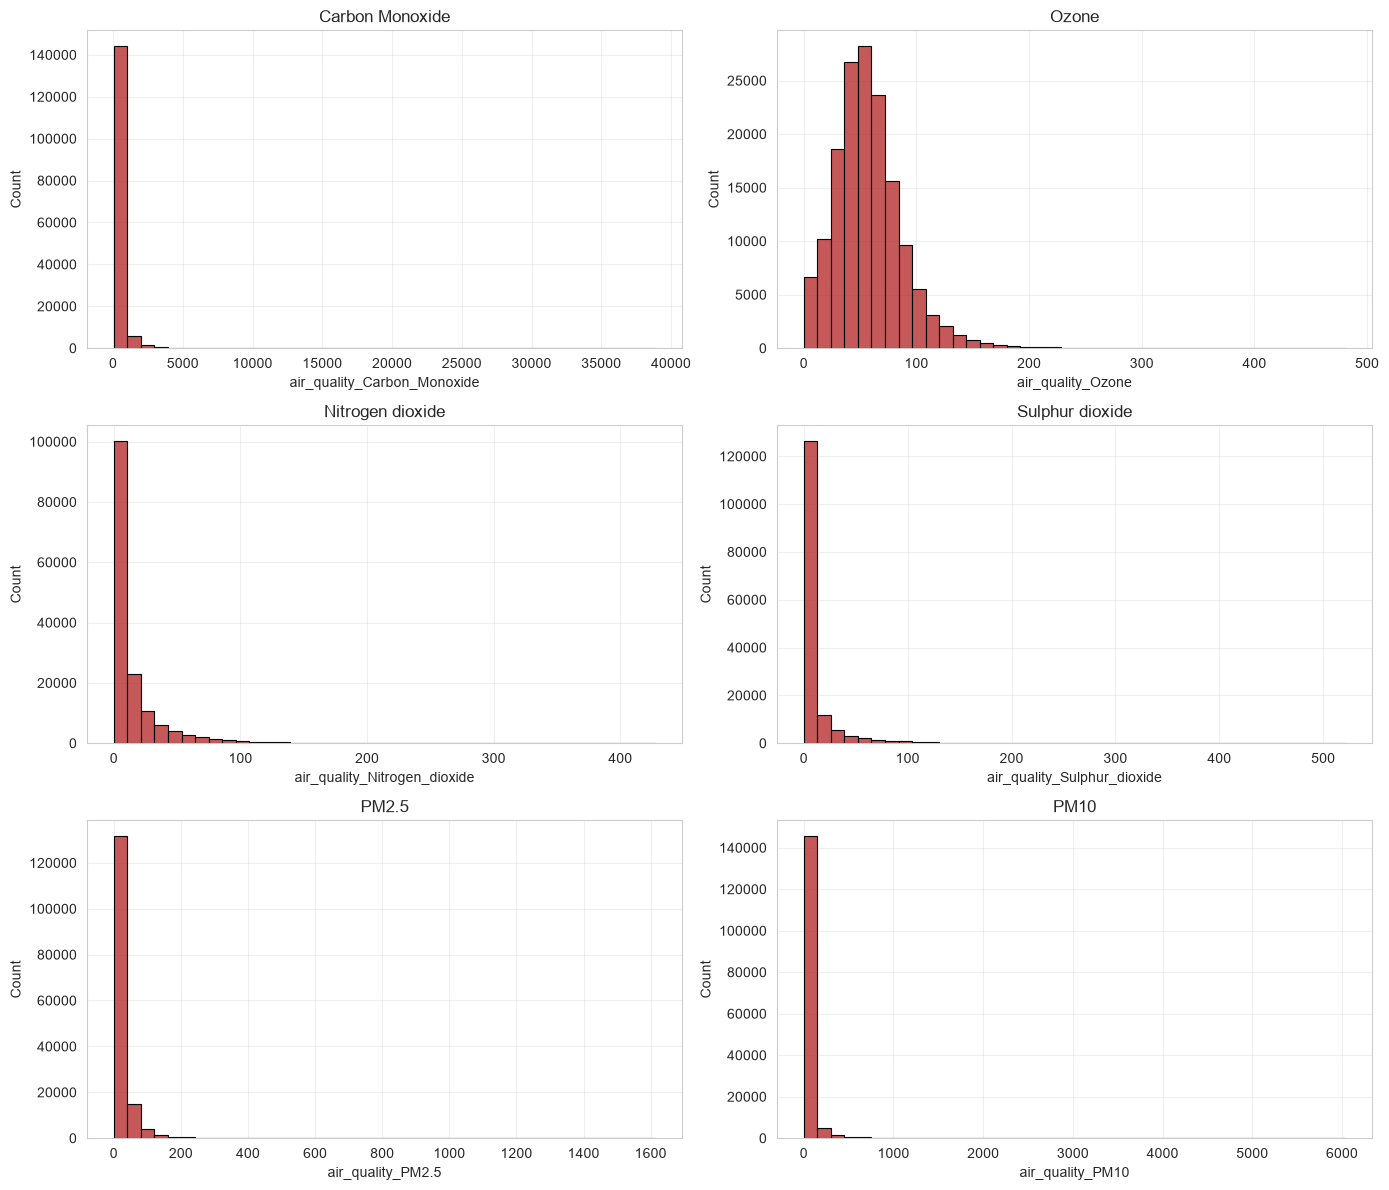

In [21]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
for ax, column in zip(axes.flat, air_quality_columns):
    sns.histplot(df[column], bins=40, ax=ax, color='firebrick', edgecolor='black')
    ax.set_title(column.replace('air_quality_', '').replace('_', ' '))
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Insight:** Every pollutant is heavily right-skewed,most readings are low/clean, with a long tail of extreme pollution events (e.g. PM2.5 maxes out at **1,614 µg/m³**, roughly 100× the WHO daily guideline, driven by rare severe-smog episodes rather than typical conditions).

### 9.1 Air Quality vs Weather Variables

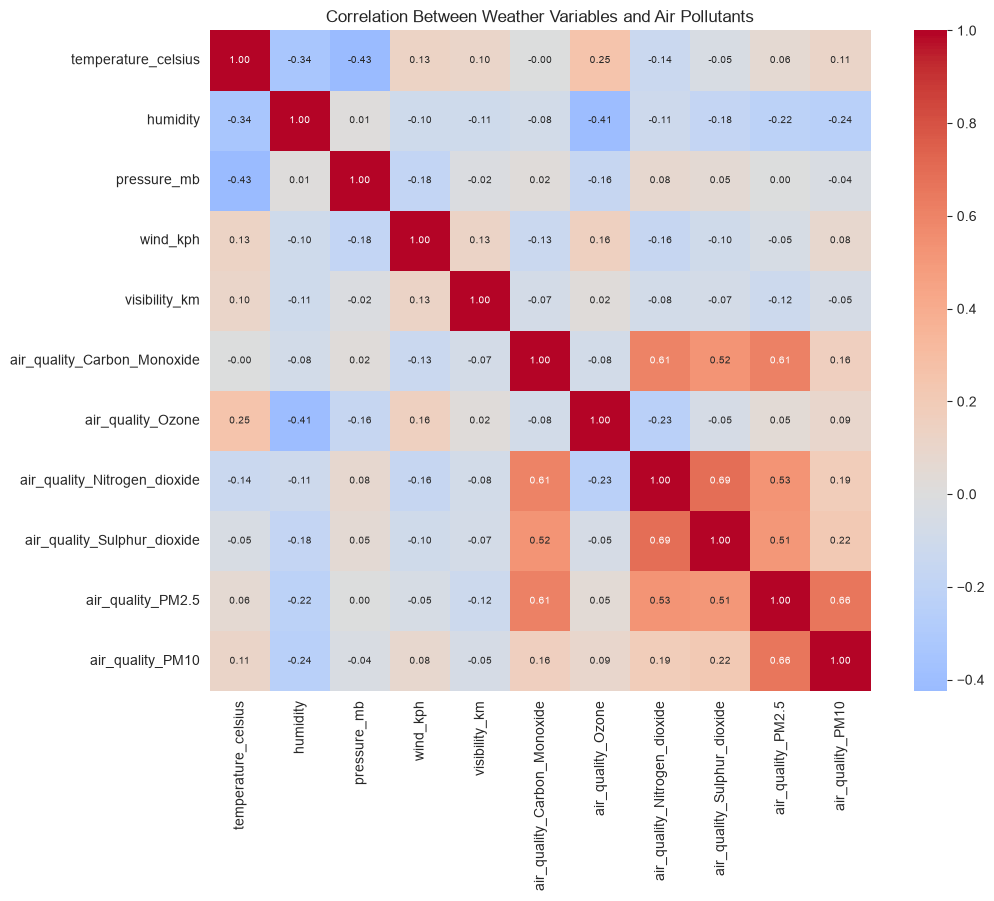

In [22]:
weather_air_columns = ['temperature_celsius', 'humidity', 'pressure_mb', 'wind_kph',
                        'visibility_km'] + air_quality_columns

corr_air = df[weather_air_columns].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr_air, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, annot_kws={'size': 7})
plt.title('Correlation Between Weather Variables and Air Pollutants')
plt.tight_layout()
plt.show()

**Insight:** The pollutants correlate strongly *with each other* (PM2.5 vs PM10: r = 0.66, PM2.5 vs CO: r = 0.61), a sign they share common sources (combustion, traffic, industry), but only weakly with the meteorological variables. Humidity has the strongest weather link to PM2.5 (r = -0.22, i.e. more humid conditions are mildly associated with lower particulate levels), and visibility is only weakly negatively correlated with PM2.5 (r = -0.12) despite the intuitive expectation that more particulates should reduce visibility more strongly, other factors like fog/mist clearly dominate visibility instead.

### 9.2 Pollution by Weather Condition

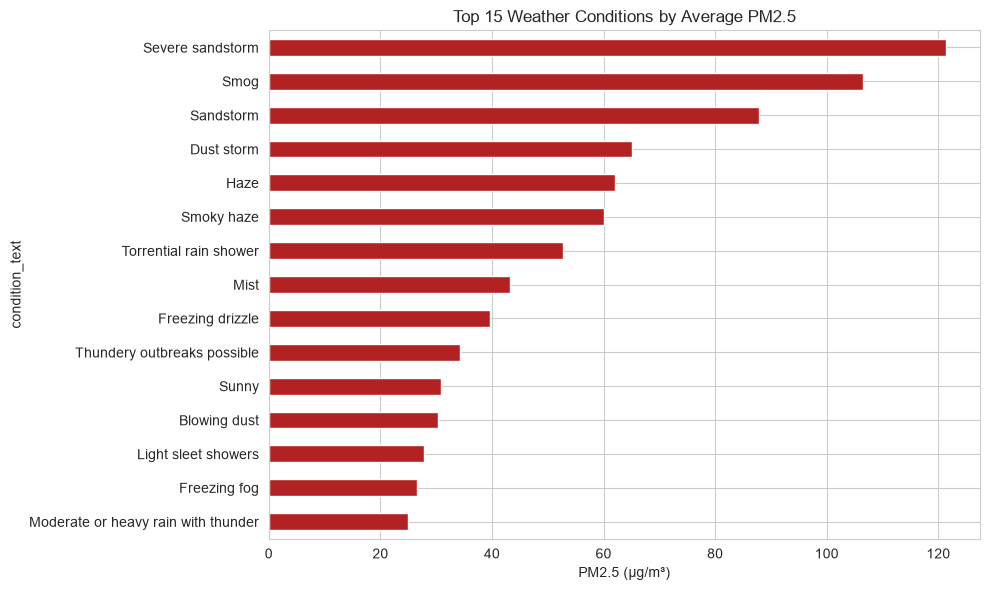

In [23]:
pm_condition = df.groupby('condition_text')['air_quality_PM2.5'].mean().sort_values()

plt.figure(figsize=(10, 6))
pm_condition.tail(15).plot(kind='barh', color='firebrick')
plt.title('Top 15 Weather Conditions by Average PM2.5')
plt.xlabel('PM2.5 (µg/m³)')
plt.tight_layout()
plt.show()

### 9.3 Air Quality by Month

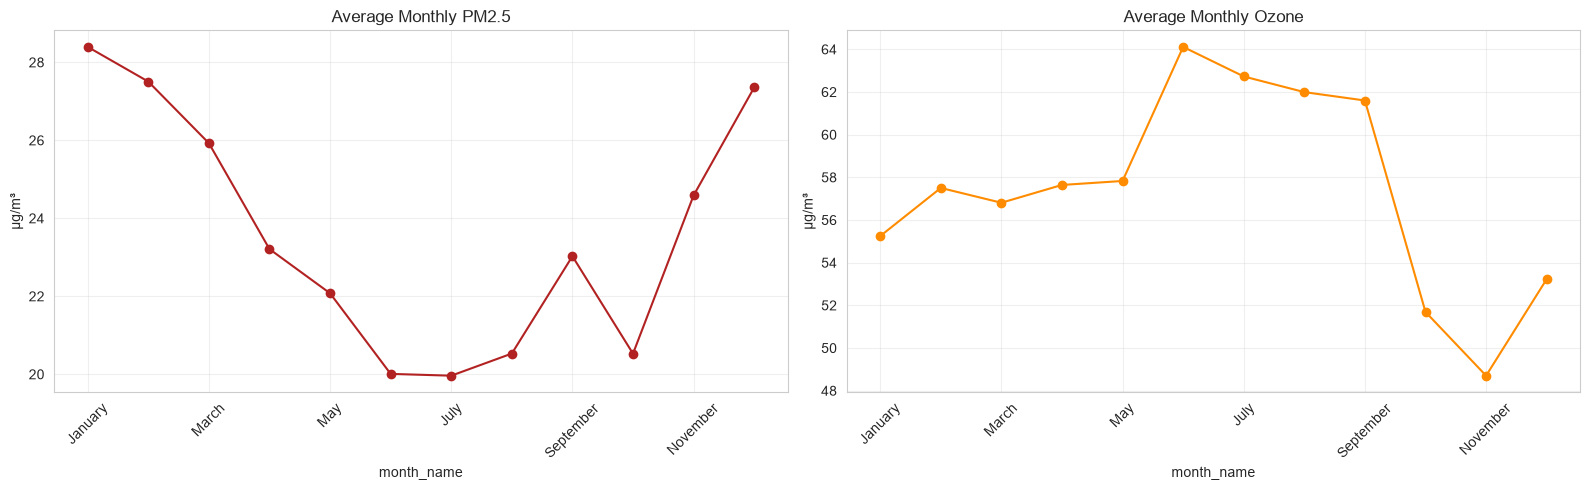

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df.groupby('month_name', observed=False)['air_quality_PM2.5'].mean().reindex(month_order).plot(
    marker='o', ax=axes[0], color='firebrick')
axes[0].set_title('Average Monthly PM2.5')
axes[0].set_ylabel('µg/m³')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(alpha=0.3)

df.groupby('month_name', observed=False)['air_quality_Ozone'].mean().reindex(month_order).plot(
    marker='o', ax=axes[1], color='darkorange')
axes[1].set_title('Average Monthly Ozone')
axes[1].set_ylabel('µg/m³')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Insight:** PM2.5 and Ozone move in *opposite* seasonal directions. PM2.5 peaks in winter (January: 28.4 µg/m³) and troughs in summer (July: 20.0 µg/m³), consistent with winter heating emissions and stagnant cold-air inversions trapping particulates. Ozone does the reverse, peaking in summer (June: 64.1 µg/m³) and troughing in winter (November: 48.7 µg/m³), since ozone forms photochemically and needs strong sunlight.

<a id='10'></a>
## 10. Geographic Analysis

### 10.1 Latitude vs Temperature

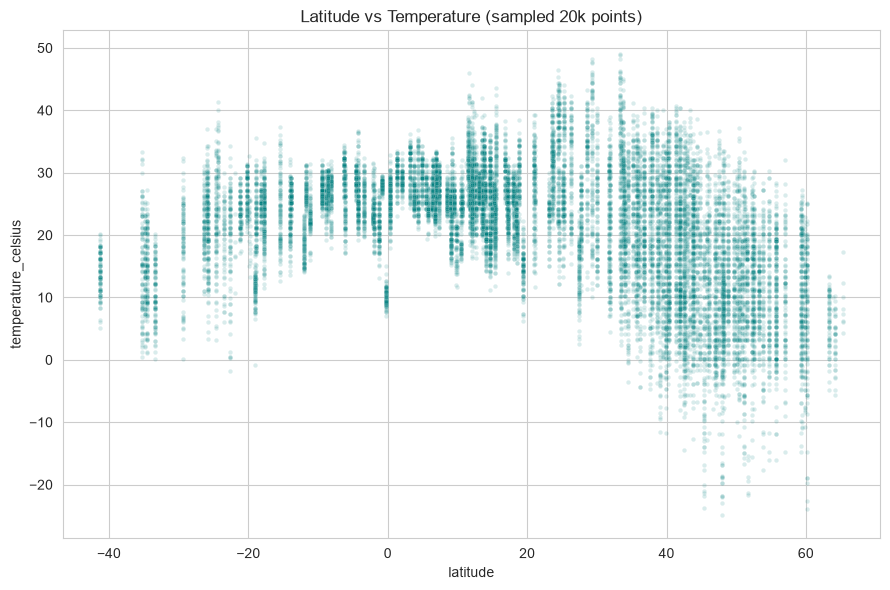

In [25]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df.sample(20000, random_state=1), x='latitude', y='temperature_celsius',
                 alpha=0.15, s=10, color='teal')
plt.title('Latitude vs Temperature (sampled 20k points)')
plt.tight_layout()
plt.show()

**Insight:** Temperature and absolute latitude are moderately negatively correlated (r ≈ -0.56) — the classic pattern of warmer temperatures near the equator, cooler toward the poles — though the scatter is wide because season, altitude, and local climate all add substantial variation on top of latitude alone.

### 10.2 Coolest & Hottest Locations

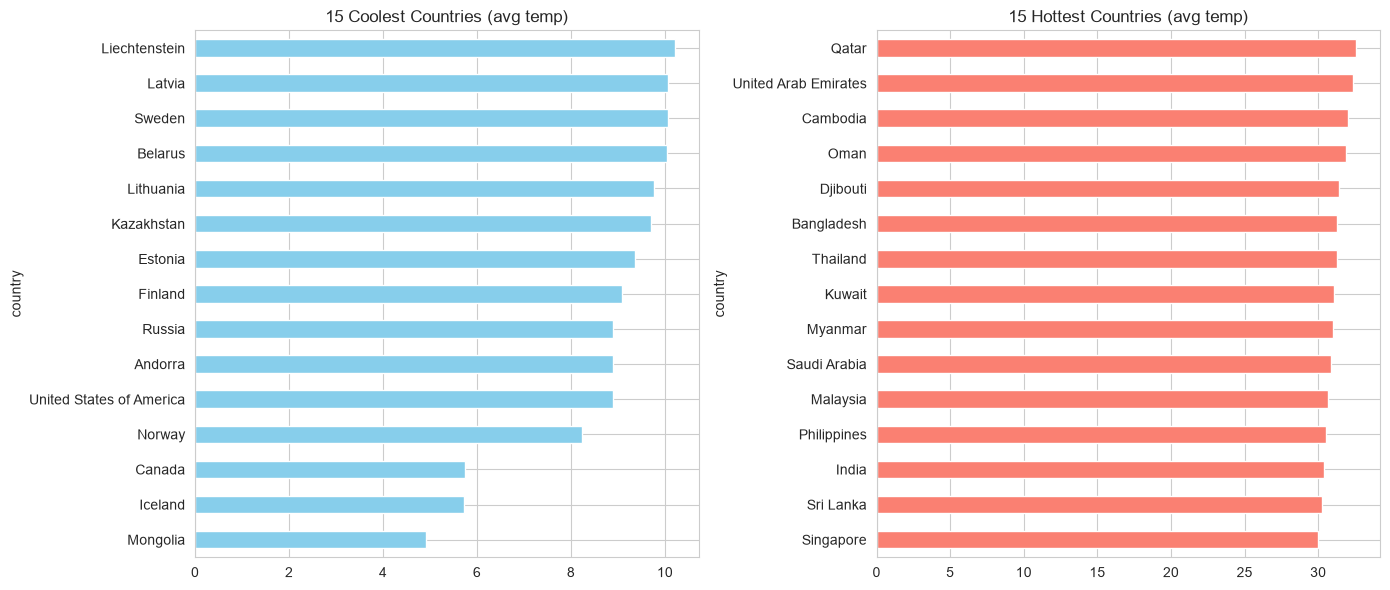

In [26]:
avg_temp_country = df.groupby('country')['temperature_celsius'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
avg_temp_country.head(15).plot(kind='barh', ax=axes[0], color='skyblue')
axes[0].set_title('15 Coolest Countries (avg temp)')
avg_temp_country.tail(15).plot(kind='barh', ax=axes[1], color='salmon')
axes[1].set_title('15 Hottest Countries (avg temp)')
plt.tight_layout()
plt.show()

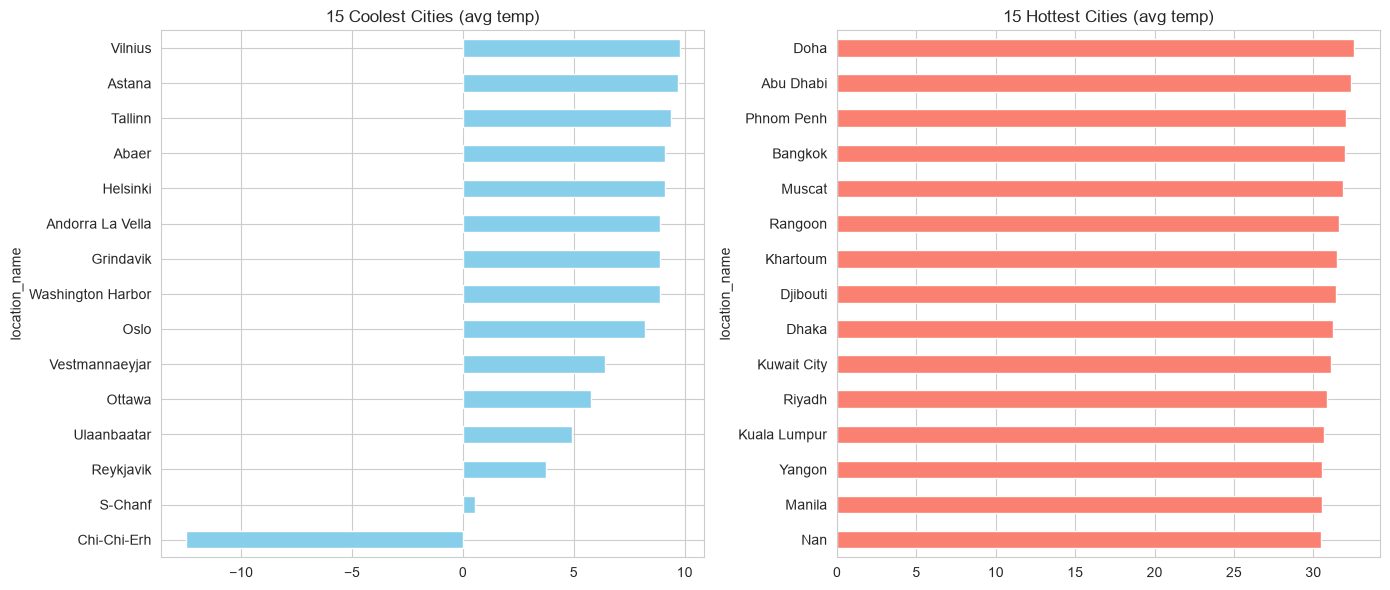

In [27]:
avg_temp_city = df.groupby('location_name')['temperature_celsius'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
avg_temp_city.head(15).plot(kind='barh', ax=axes[0], color='skyblue')
axes[0].set_title('15 Coolest Cities (avg temp)')
avg_temp_city.tail(15).plot(kind='barh', ax=axes[1], color='salmon')
axes[1].set_title('15 Hottest Cities (avg temp)')
plt.tight_layout()
plt.show()

**Insight:** Coolest countries (Mongolia 4.9°C, Iceland 5.7°C, Canada 5.8°C) and hottest (Qatar 32.6°C, UAE 32.4°C, Cambodia 32.1°C) both align with well-known climate profiles, which is a good sanity check that the location/temperature mapping in the data is trustworthy.

### 10.3 Pollution by Country

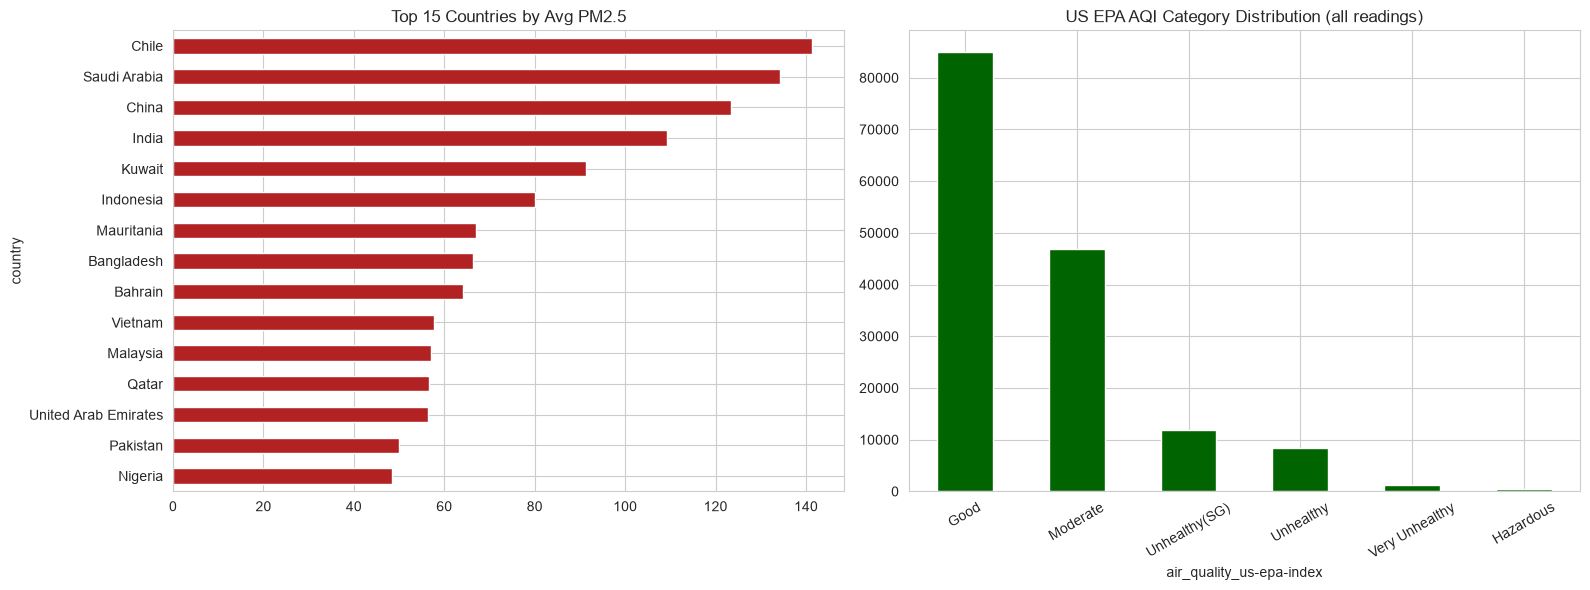

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df.groupby('country')['air_quality_PM2.5'].mean().sort_values(ascending=False).head(15).plot(
    kind='barh', ax=axes[0], color='firebrick')
axes[0].set_title('Top 15 Countries by Avg PM2.5')
axes[0].invert_yaxis()

epa_labels = {1: 'Good', 2: 'Moderate', 3: 'Unhealthy(SG)', 4: 'Unhealthy',
              5: 'Very Unhealthy', 6: 'Hazardous'}
df['air_quality_us-epa-index'].map(epa_labels).value_counts().reindex(epa_labels.values()).plot(
    kind='bar', ax=axes[1], color='darkgreen')
axes[1].set_title('US EPA AQI Category Distribution (all readings)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**Insight:** Chile (141 µg/m³ avg PM2.5), Saudi Arabia (134), and China (123) top the pollution ranking — Chile's figure is driven by Santiago's well-documented winter thermal-inversion smog events rather than a uniformly polluted country. Globally, most individual readings still fall in 'Good' or 'Moderate' territory, but the tail of 'Unhealthy'+ readings is far from negligible.

### 10.4 Interactive World Maps

The bar charts above give precise rankings; these maps show the *spatial pattern* at a glance — useful for spotting regional clusters that a ranked list hides. This needs `plotly`, which isn't a hard requirement for the rest of the notebook, so the import is guarded: if it's not installed, this cell prints a message and the rest of the notebook still runs normally.

In [29]:
try:
    import plotly.express as px
    PLOTLY_AVAILABLE = True
except ImportError:
    PLOTLY_AVAILABLE = False
    print('plotly not installed — skip interactive maps, or `pip install plotly` and re-run this cell.')

if PLOTLY_AVAILABLE:
    country_map = df.groupby('country', as_index=False).agg(
        observations=('country', 'size'),
        mean_temperature=('temperature_celsius', 'mean'),
        mean_pm25=('air_quality_PM2.5', 'mean'),
        mean_uv=('uv_index', 'mean'),
    )
    display(country_map.head())

,country,observations,mean_temperature,mean_pm25,mean_uv
0,Afghanistan,791,19.460430,18.419589,6.248799
1,Albania,790,19.406329,14.535924,3.015063
2,Algeria,789,20.262864,18.270406,2.316350
3,Andorra,791,8.896081,4.757986,1.859166
4,Angola,791,25.734893,29.451138,3.963085


In [30]:
if PLOTLY_AVAILABLE:
    fig_temp = px.choropleth(
        country_map, locations='country', locationmode='country names',
        color='mean_temperature', color_continuous_scale='RdYlBu_r',
        labels={'mean_temperature': 'Mean Temperature (°C)'},
        title='Average Temperature by Country'
    )
    fig_temp.update_geos(projection_type='natural earth', showcoastlines=True,
                          showframe=False, showcountries=True, fitbounds=False)
    fig_temp.update_layout(margin=dict(l=0, r=0, t=50, b=0))
    fig_temp.show()

C:\Users\Aeiman Imtiaz\AppData\Local\Temp\ipykernel_20008\3243068456.py:2: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig_temp = px.choropleth(


In [31]:
if PLOTLY_AVAILABLE:
    fig_pm25 = px.choropleth(
        country_map, locations='country', locationmode='country names',
        color='mean_pm25', color_continuous_scale='YlOrRd',
        labels={'mean_pm25': 'Mean PM2.5 (µg/m³)'},
        title='Average PM2.5 Pollution by Country'
    )
    fig_pm25.update_geos(projection_type='natural earth', showcoastlines=True,
                          showframe=False, showcountries=True, fitbounds=False)
    fig_pm25.update_layout(margin=dict(l=0, r=0, t=50, b=0))
    fig_pm25.show()

C:\Users\Aeiman Imtiaz\AppData\Local\Temp\ipykernel_20008\4265629549.py:2: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig_pm25 = px.choropleth(


**Insight:** The temperature map makes the latitude-band pattern from Section 10.1 visually obvious — a smooth gradient from the equator outward. The PM2.5 map looks completely different: pollution is patchy rather than banded, with isolated hotspots (East/South Asia, the Gulf, Chile) standing out against a mostly clean map. That contrast is the clearest evidence in this whole notebook that temperature is climate-driven while PM2.5 is source-driven (industry, traffic, local geography) rather than latitude-driven.

<a id='12'></a>
## 12. Livability Index

A custom composite comfort score (0-100) blending temperature comfort, humidity comfort, wind comfort, air quality, and UV safety. Weights: temperature 35%, air quality 25%, humidity 15%, UV 15%, wind 10% — reflecting that extreme heat/cold and pollution matter most for day-to-day comfort.

To keep the country ranking reliable, countries are also required to have at least **400 observations** across **8+ distinct months** before they're included — this avoids a country with only a handful of readings (e.g. all from one mild week) landing at the top by chance. Countries are also rewarded for *consistency*: a country with a high average score but wildly variable weather is ranked slightly below one with the same average but more stable conditions.

In [32]:
def temp_comfort(t):
    return np.clip(100 - np.abs(t - 21) * 3.0, 0, 100)          # highest score at 21°C

def humidity_comfort(h):
    return np.clip(100 - np.abs(h - 50) * 1.2, 0, 100)          # highest score at 50% RH

def wind_comfort(w):
    return np.clip(100 - np.abs(w - 10) * 1.5, 0, 100)          # highest score at ~10 kph

def aqi_comfort(idx):
    return np.clip(100 - (idx - 1) * 20, 0, 100)                # US EPA index: 1=best, 6=worst

def uv_comfort(uv):
    return np.clip(100 - np.maximum(uv - 3, 0) * 8, 0, 100)     # no penalty up to UV 3

df['temperature_comfort'] = temp_comfort(df['temperature_celsius'])
df['humidity_comfort'] = humidity_comfort(df['humidity'])
df['wind_comfort'] = wind_comfort(df['wind_kph'])
df['air_quality_comfort'] = aqi_comfort(df['air_quality_us-epa-index'])
df['uv_comfort'] = uv_comfort(df['uv_index'])

df['livability_score'] = (
    0.35 * df['temperature_comfort'] + 0.15 * df['humidity_comfort'] +
    0.10 * df['wind_comfort'] + 0.25 * df['air_quality_comfort'] + 0.15 * df['uv_comfort']
)

In [33]:
# Reliability filter: require enough spread of observations before ranking a country
df['year_month'] = df['last_updated'].dt.to_period('M')

livability_summary = df.groupby('country').agg(
    observations=('livability_score', 'size'),
    months_covered=('year_month', 'nunique'),
    mean_score=('livability_score', 'mean'),
    score_std=('livability_score', 'std'),
)

MIN_OBSERVATIONS = 400
MIN_MONTHS = 8

eligible = livability_summary[
    (livability_summary['observations'] >= MIN_OBSERVATIONS) &
    (livability_summary['months_covered'] >= MIN_MONTHS)
].copy()

print(f'Total countries: {livability_summary.shape[0]}  |  Eligible after filtering: {eligible.shape[0]}')

Total countries: 186  |  Eligible after filtering: 185


In [34]:
# Reward consistency: countries with more stable scores rank slightly higher than
# equally-average-but-volatile countries.
eligible['stability_score'] = (100 - eligible['score_std'] * 2).clip(0, 100)
eligible['adjusted_livability_score'] = 0.85 * eligible['mean_score'] + 0.15 * eligible['stability_score']

liv_country = eligible.sort_values('adjusted_livability_score', ascending=False)

display(liv_country[['observations', 'months_covered', 'mean_score',
                      'stability_score', 'adjusted_livability_score']].head(15).round(2))

,observations,months_covered,mean_score,stability_score,adjusted_livability_score
country,,,,,
Costa Rica,767,27,89.52,90.64,89.69
Honduras,785,27,89.02,93.12,89.64
Paraguay,738,26,89.62,89.50,89.61
Fiji Islands,790,27,88.25,94.66,89.21
Nicaragua,785,27,88.41,92.75,89.06
Timor-Leste,787,27,87.79,94.17,88.75
Monaco,787,27,88.36,90.63,88.70
Belize,786,27,87.63,94.33,88.64
Brazil,785,27,87.60,93.20,88.44


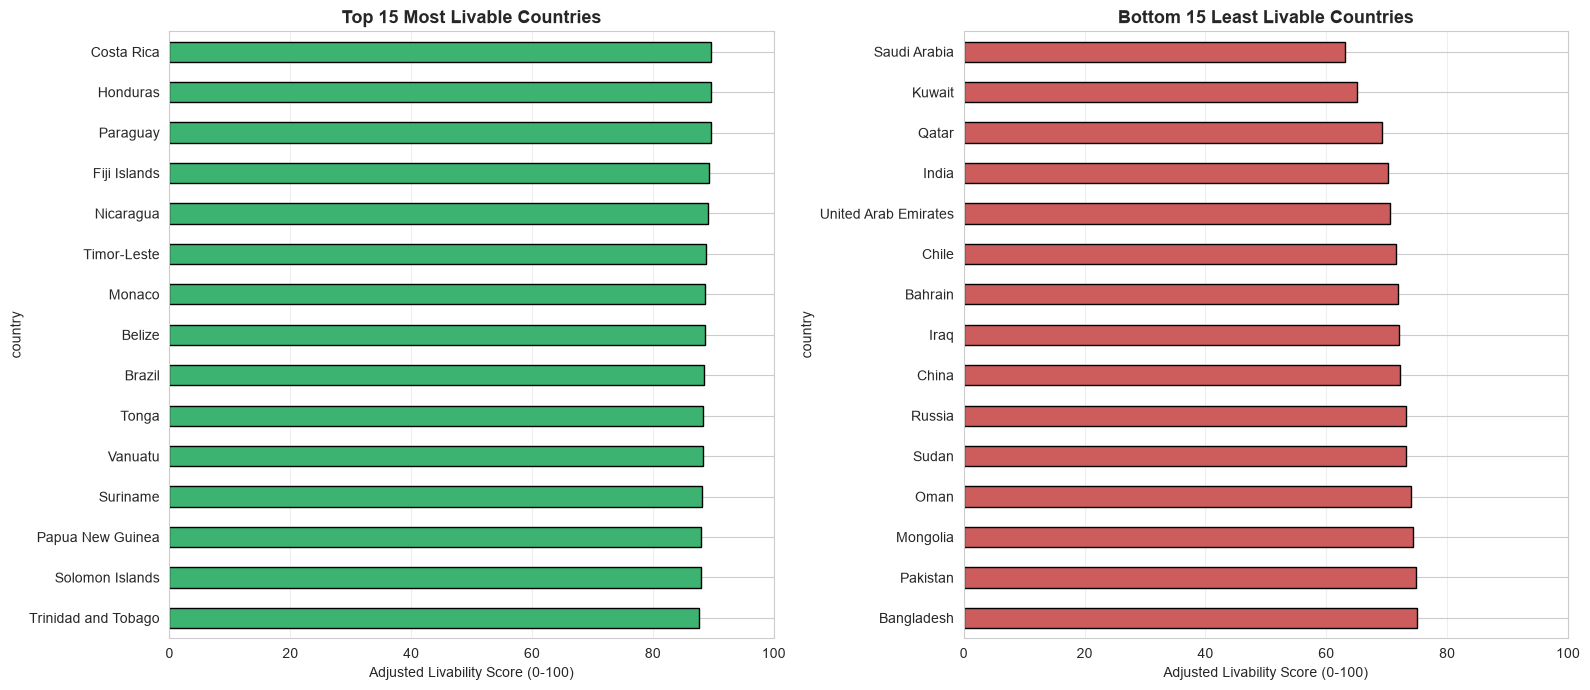

In [35]:
top_n = 15
top_countries = liv_country.head(top_n).sort_values('adjusted_livability_score')
bottom_countries = liv_country.tail(top_n).sort_values('adjusted_livability_score', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top_countries['adjusted_livability_score'].plot(kind='barh', ax=axes[0], color='mediumseagreen', edgecolor='black')
axes[0].set_title('Top 15 Most Livable Countries', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Adjusted Livability Score (0-100)')
axes[0].set_xlim(0, 100)
axes[0].grid(axis='x', alpha=0.3)

bottom_countries['adjusted_livability_score'].plot(kind='barh', ax=axes[1], color='indianred', edgecolor='black')
axes[1].set_title('Bottom 15 Least Livable Countries', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Adjusted Livability Score (0-100)')
axes[1].set_xlim(0, 100)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

**Insight:** Mild tropical/coastal climates dominate the top of the ranking (Costa Rica, Honduras, Paraguay, Fiji, Nicaragua) — moderate temperatures and cleaner air outweigh their humidity, and the consistency bonus rewards their lack of extreme swings. The bottom is a mix of two distinct failure modes rather than just 'hot countries': Gulf states (Saudi Arabia, Kuwait, Qatar, UAE) and India/Bangladesh/Pakistan are penalized by extreme heat and/or heavy pollution, while Mongolia and Russia land near the bottom too — driven by cold and wind extremes rather than heat. This is a more balanced picture than a heat-only ranking would give. As always, this score is a simplified illustration, not a rigorous index — the weights are subjective and could be tuned to prioritize different factors.

<a id='13'></a>
## 13. Best Time to Visit

A monthly comfort score per country: warm-but-not-hot temperatures (40%), moderate humidity (20%), low rainfall (25%), and moderate UV (15%),tuned toward what makes a pleasant trip rather than year-round comfort.

In [36]:
monthly = df.groupby(['country', 'month_name'], observed=False).agg(
    temp=('temperature_celsius', 'mean'),
    humidity=('humidity', 'mean'),
    precip=('precip_mm', 'mean'),
    uv=('uv_index', 'mean'),
).reset_index()

def temp_comfort_v(t): return np.clip(100 - np.abs(t - 23) * 3.0, 0, 100)
def humidity_comfort_v(h): return np.clip(100 - np.abs(h - 50) * 1.0, 0, 100)
def precip_comfort_v(p): return np.clip(100 - p * 40, 0, 100)
def uv_comfort_v(uv): return np.clip(100 - np.maximum(uv - 3, 0) * 8, 0, 100)

monthly['visit_score'] = (
    temp_comfort_v(monthly['temp']) * 0.4 +
    humidity_comfort_v(monthly['humidity']) * 0.2 +
    precip_comfort_v(monthly['precip']) * 0.25 +
    uv_comfort_v(monthly['uv']) * 0.15
)

best_month = monthly.loc[monthly.groupby('country')['visit_score'].idxmax()][
    ['country', 'month_name', 'visit_score', 'temp', 'precip']]
best_month = best_month.sort_values('visit_score', ascending=False)
best_month.head(15)

,country,month_name,visit_score,temp,precip
818,Guinea-Bissau,December,99.659677,23.209677,0.002419
1547,Paraguay,September,99.178667,22.876667,0.000000
722,Gambia,December,99.158387,22.872581,0.000484
1221,Mali,November,99.158000,23.485000,0.000000
1256,Mauritania,May,98.246076,23.231646,0.000000
778,Greece,October,98.212258,22.222581,0.069355
1089,Lebanon,November,98.177000,22.810000,0.071500
1598,Qatar,December,98.088387,23.848387,0.000968
1718,Senegal,December,98.064194,22.933871,0.003387
2092,United Arab Emirates,January,98.012131,22.647541,0.000820


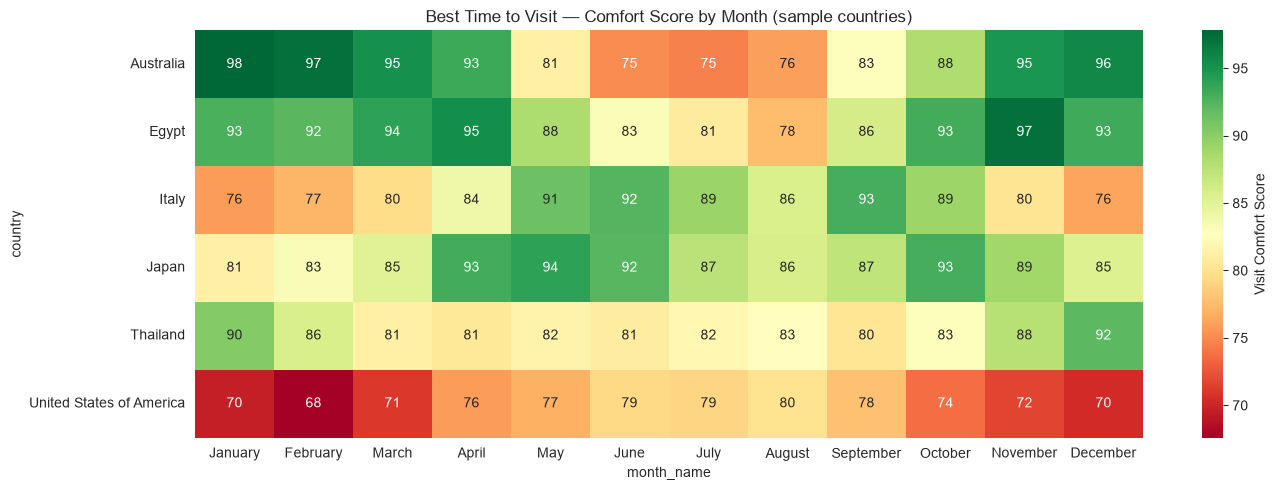

In [37]:
# Heatmap for a sample of popular tourist countries
sample_countries = ['Thailand', 'Italy', 'Japan', 'Egypt', 'Australia', 'United States of America']
sample_countries = [c for c in sample_countries if c in monthly['country'].unique()]

pivot = monthly[monthly['country'].isin(sample_countries)].pivot(
    index='country', columns='month_name', values='visit_score').reindex(columns=month_order)

plt.figure(figsize=(14, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn', cbar_kws={'label': 'Visit Comfort Score'})
plt.title('Best Time to Visit — Comfort Score by Month (sample countries)')
plt.tight_layout()
plt.show()

**Insight:** Results line up with conventional travel wisdom: Greece scores best in October, Australia in January (its summer), and Egypt in November,each avoiding that country's harshest heat or rain season.


<a id='14'></a>
## 14. Rush Hour Pollution Patterns
The average hourly concentration of each pollutant was first calculated. To enable comparison between pollutants with different concentration ranges, Min-Max normalization was applied independently to each pollutant, scaling the hourly averages to a range between 0 and 1. This preserves the temporal pattern while removing differences in magnitude, allowing the hourly trends of all pollutants to be compared on the same scale.

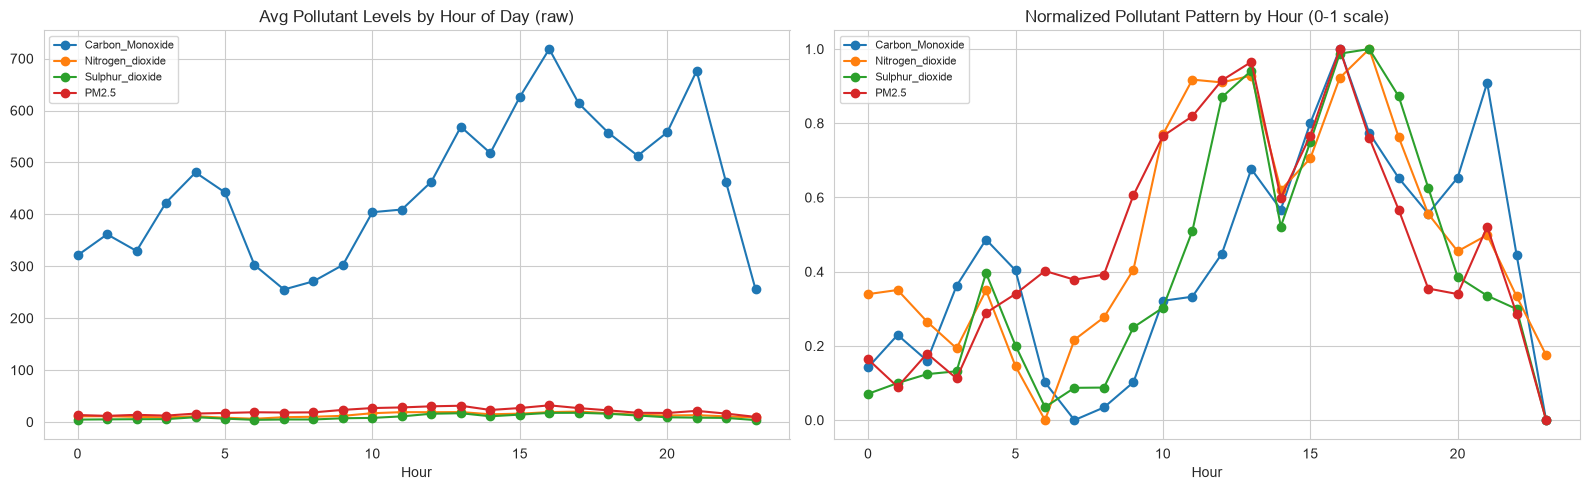

In [38]:
pollutants = ['air_quality_Carbon_Monoxide', 'air_quality_Nitrogen_dioxide',
              'air_quality_Sulphur_dioxide', 'air_quality_PM2.5']

hourly_poll = df.groupby('hour')[pollutants].mean()
hourly_norm = (hourly_poll - hourly_poll.min()) / (hourly_poll.max() - hourly_poll.min())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for col in pollutants:
    axes[0].plot(hourly_poll.index, hourly_poll[col], marker='o', label=col.replace('air_quality_', ''))
axes[0].set_title('Avg Pollutant Levels by Hour of Day (raw)')
axes[0].set_xlabel('Hour')
axes[0].legend(fontsize=8)

for col in pollutants:
    axes[1].plot(hourly_norm.index, hourly_norm[col], marker='o', label=col.replace('air_quality_', ''))
axes[1].set_title('Normalized Pollutant Pattern by Hour (0-1 scale)')
axes[1].set_xlabel('Hour')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

,Weekday,Weekend
air_quality_Carbon_Monoxide,437.271871,425.458947
air_quality_Nitrogen_dioxide,14.917078,13.123631
air_quality_Sulphur_dioxide,10.130431,9.455636
air_quality_PM2.5,23.416335,23.108831


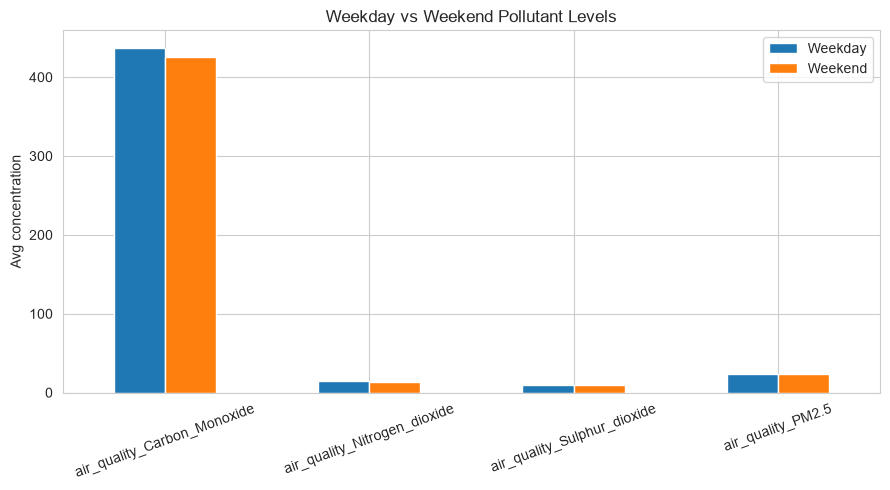

In [39]:
df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday'])
weekday_vs_weekend = df.groupby('is_weekend')[pollutants].mean().T
weekday_vs_weekend.columns = ['Weekday', 'Weekend']
display(weekday_vs_weekend)

weekday_vs_weekend.plot(kind='bar', figsize=(9, 5))
plt.title('Weekday vs Weekend Pollutant Levels')
plt.ylabel('Avg concentration')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Insight:** Pollutants trough overnight (~23:00-07:00) and build through the day, peaking in the afternoon/early evening (~16:00-21:00) rather than showing two sharp AM/PM traffic spikes, more a broad daytime buildup than a classic double rush-hour pattern. All four pollutants are also modestly higher on weekdays than weekends (NO2 shows the largest gap: 14.9 vs 13.1), consistent with a traffic/industrial activity signature.

<a id='15'></a>
## 15. Wind Power Potential

Wind power density scales roughly with speed cubed. Countries are assigned a simplified wind-power class based on average speed in m/s (a rough proxy, not a substitute for real site surveys).

In [40]:
df['wind_ms'] = df['wind_kph'] / 3.6

wind_country = df.groupby('country').agg(
    avg_wind_kph=('wind_kph', 'mean'),
    avg_gust_kph=('gust_kph', 'mean'),
    pct_above_20kph=('wind_kph', lambda x: (x > 20).mean() * 100),
    mean_cubed_ms=('wind_ms', lambda x: (x ** 3).mean())
).sort_values('avg_wind_kph', ascending=False)

def wind_class(ms):
    if ms < 4.4: return 'Class 1 (Poor)'
    elif ms < 5.1: return 'Class 2 (Marginal)'
    elif ms < 5.6: return 'Class 3 (Fair)'
    elif ms < 6.0: return 'Class 4 (Good)'
    elif ms < 6.4: return 'Class 5 (Excellent)'
    elif ms < 7.0: return 'Class 6 (Outstanding)'
    else: return 'Class 7 (Superb)'

wind_country['avg_wind_ms'] = wind_country['avg_wind_kph'] / 3.6
wind_country['wind_class'] = wind_country['avg_wind_ms'].apply(wind_class)
wind_country.head(10)

,avg_wind_kph,avg_gust_kph,pct_above_20kph,mean_cubed_ms,avg_wind_ms,wind_class
country,,,,,,
Somalia,26.924461,32.452725,83.396705,489.662027,7.479017,Class 7 (Superb)
Saint Vincent and the Grenadines,26.641371,36.454569,85.152284,481.013146,7.400381,Class 7 (Superb)
Saint Kitts and Nevis,26.276426,38.251331,78.833967,723.340633,7.299007,Class 7 (Superb)
Antigua and Barbuda,25.038931,36.502290,74.554707,437.050198,6.955259,Class 6 (Outstanding)
Barbados,24.872497,35.042332,76.932826,410.762844,6.909027,Class 6 (Outstanding)
New Zealand,24.820886,37.736582,60.379747,625.511050,6.894691,Class 6 (Outstanding)
Iceland,23.363878,34.588466,49.556401,670.799893,6.489966,Class 6 (Outstanding)
Tonga,23.281321,33.606099,60.482846,437.604047,6.467034,Class 6 (Outstanding)
Azerbaijan,22.969873,30.075570,53.797468,511.555196,6.380520,Class 5 (Excellent)


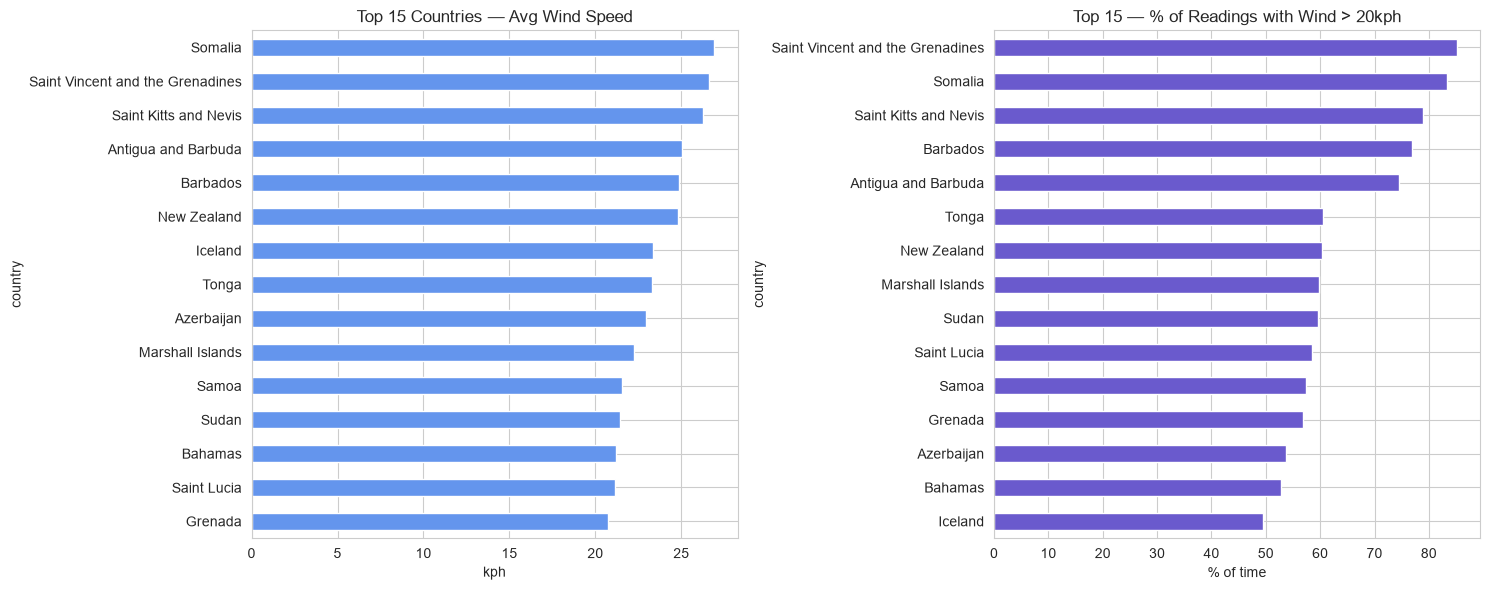

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
wind_country.head(15)['avg_wind_kph'].sort_values().plot(kind='barh', ax=axes[0], color='cornflowerblue')
axes[0].set_title('Top 15 Countries — Avg Wind Speed')
axes[0].set_xlabel('kph')

wind_country.head(15)['pct_above_20kph'].sort_values().plot(kind='barh', ax=axes[1], color='slateblue')
axes[1].set_title('Top 15 — % of Readings with Wind > 20kph')
axes[1].set_xlabel('% of time')
plt.tight_layout()
plt.show()

In [42]:
wind_country['wind_class'].value_counts()

wind_class
Class 1 (Poor)           142
Class 2 (Marginal)        16
Class 3 (Fair)            10
Class 4 (Good)             8
Class 6 (Outstanding)      5
Class 7 (Superb)           3
Class 5 (Excellent)        2
Name: count, dtype: int64

**Insight:** Top average wind speeds cluster around small island nations exposed to open ocean (Somalia, St. Vincent & the Grenadines, St. Kitts and Nevis, Antigua and Barbuda) plus classically windy regions (New Zealand, Iceland). Using the simplified wind-class scale, the large majority of countries fall in 'Class 1 (Poor)', strong, consistent wind resource is the exception rather than the rule in this sample. Note this is single-point city-level data, not a true site survey, so it's only a rough screening tool, not a substitute for real wind-farm siting studies.

<a id='16'></a>
## 16. UV Index Extremes by Country

### 16.1 Ranking by Country

In [43]:
uv_country = df.groupby('country')['uv_index'].agg(['mean', 'max']).sort_values('mean', ascending=False)
uv_country.head(10)

,mean,max
country,,
Seychelles Islands,9.572589,14.8
Somalia,8.577060,14.7
Yemen,8.335732,15.4
Madagascar,8.234588,16.0
Tanzania,8.146962,15.6
Kenya,8.146776,16.0
Maldives,8.072137,13.9
Comoros,8.061294,14.7
Mauritius,7.935190,14.2


In [44]:
df.nlargest(10, 'uv_index')[['country', 'location_name', 'uv_index', 'last_updated']]

,country,location_name,uv_index,last_updated
52185,Zambia,Lusaka,16.3,2025-02-10 12:30:00
47280,South Africa,Pretoria,16.1,2025-01-16 12:00:00
45306,Madagascar,Antananarivo,16.0,2025-01-06 12:45:00
46533,Zimbabwe,Harare,16.0,2025-01-12 12:30:00
47118,Zimbabwe,Harare,16.0,2025-01-15 12:30:00
53652,Malawi,Lilongwe,16.0,2025-02-18 12:00:00
53743,Zambia,Lusaka,16.0,2025-02-18 12:15:00
58282,Ethiopia,Addis Ababa,16.0,2025-03-14 12:45:00
59873,Kenya,Nairobi,16.0,2025-03-22 12:30:00
46653,Namibia,Windhoek,15.9,2025-01-13 13:30:00


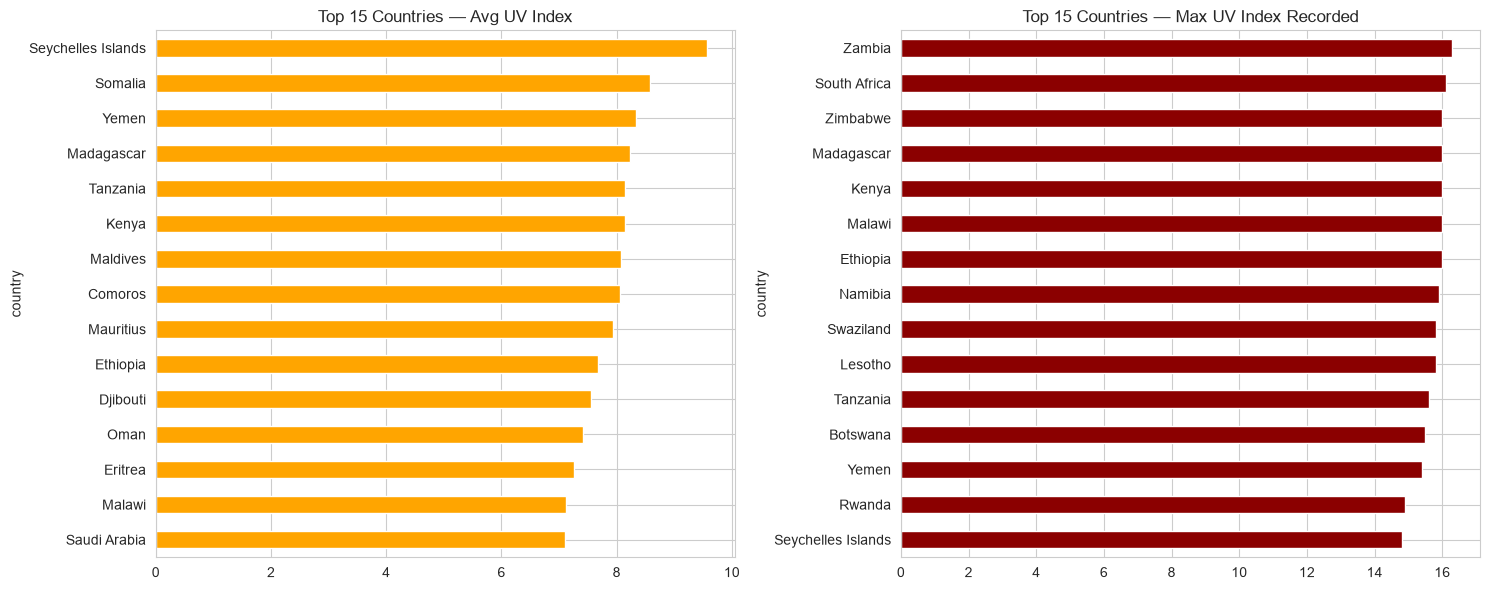

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
uv_country.head(15)['mean'].sort_values().plot(kind='barh', ax=axes[0], color='orange')
axes[0].set_title('Top 15 Countries — Avg UV Index')

uv_country.sort_values('max', ascending=False).head(15)['max'].sort_values().plot(
    kind='barh', ax=axes[1], color='darkred')
axes[1].set_title('Top 15 Countries — Max UV Index Recorded')
plt.tight_layout()
plt.show()

### 16.2 Interactive Map

In [46]:
if PLOTLY_AVAILABLE:
    fig_uv = px.choropleth(
        country_map, locations='country', locationmode='country names',
        color='mean_uv', color_continuous_scale='Plasma',
        labels={'mean_uv': 'Mean UV Index'},
        title='Average UV Index by Country'
    )
    fig_uv.update_geos(projection_type='natural earth', showcoastlines=True,
                        showframe=False, showcountries=True, fitbounds=False)
    fig_uv.update_layout(margin=dict(l=0, r=0, t=50, b=0))
    fig_uv.show()

C:\Users\Aeiman Imtiaz\AppData\Local\Temp\ipykernel_20008\1412403032.py:2: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig_uv = px.choropleth(


**Insight:** Highest average UV is concentrated in equatorial/high-altitude tropical countries (Seychelles, Somalia, Yemen, Madagascar, Tanzania, Kenya). The single highest readings recorded (16.3 in Lusaka, Zambia; 16.1 in Pretoria, South Africa) occurred in Jan-Mar — southern-hemisphere high-altitude summer sun — and sit well into the 'extreme' risk band (UV 11+). The map version makes the equatorial concentration immediately obvious, in a way the ranked bar chart alone doesn't.

<a id='17'></a>
## 17. Summary of Key Insights


- **Seasonality is strong and predictable:** temperature swings ~10°C across months and ~11°C across hours, with humidity moving inversely to temperature at both timescales.
- **Weather variables are mostly non-normal:** precipitation, wind, and UV are all right-skewed with long tails of extreme events — a reason to prefer median/IQR-based summaries over mean/std alone.
- **Feels-like temperature and wind/gust speed are near-redundant with temperature and wind speed respectively** (r > 0.9) — worth dropping one of each pair in a modeling context to avoid multicollinearity.
- **Air pollutants cluster together** (shared traffic/industrial sources) but are only weakly tied to weather conditions directly.
- **PM2.5 and Ozone have opposite seasonal cycles** — PM2.5 peaks in winter (cold-air inversions), Ozone peaks in summer (photochemical formation).
- **Pollution builds through the day** rather than showing a sharp two-peak rush hour, and is modestly higher on weekdays than weekends.
- **Geography checks out against real-world climate knowledge:** coolest/hottest countries and cities, and highest-UV countries, all match known climate profiles — a good sign the dataset is reliable.
- **Custom composite indices** (livability, best time to visit, wind power potential) turn raw weather variables into decision-ready rankings, though all rely on subjective weighting choices that could be adjusted for a different use case.